# Workshop Notebook 1 — Disease Subtyping with a Variational Autoencoder
## TCGA-BRCA Multi-Omics Integration

**Use case:** Disease subtyping  
**Model:** Variational Autoencoder (VAE)  
**Data source:** UCSC Xena — TCGA Hub  
**Status: DATA ACQUISITION & INSPECTION ONLY**

---

### Project structure
```
AI-Driven-MultiOmics-Workshop/
├── data/
│   ├── raw/          ← raw downloads from UCSC Xena (this section)
│   └── processed/    ← preprocessed matrices (future notebook)
├── notebooks/
│   └── 01_disease_subtyping_vae.ipynb   ← THIS NOTEBOOK
└── 01_VAE_MultiOmics_Subtyping.ipynb    ← archived prototype
```

### Datasets to download

| Modality | Xena dataset ID | URL |
|---|---|---|
| RNA-seq | `TCGA.BRCA.sampleMap/HiSeqV2` | S3 (gzipped TSV) |
| miRNA | `TCGA.BRCA.sampleMap/miRNA_HiSeq_gene` | S3 (gzipped TSV) |
| DNA methylation | `TCGA.BRCA.sampleMap/HumanMethylation450` | S3 (gzipped TSV) |
| Clinical/PAM50 | `TCGA.BRCA.sampleMap/BRCA_clinicalMatrix` | S3 (TSV, uncompressed) |

---
## Part 1 — Imports and path setup

In [1]:
import os
import sys
import gzip
import shutil
import hashlib
import urllib.request
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ── Paths ──────────────────────────────────────────────────────────────────────
NOTEBOOK_DIR = Path(".").resolve()
# If running from notebooks/, step up one level to project root
if NOTEBOOK_DIR.name == "notebooks":
    PROJECT_DIR = NOTEBOOK_DIR.parent
else:
    PROJECT_DIR = NOTEBOOK_DIR

RAW_DIR       = PROJECT_DIR / "data" / "raw"
PROCESSED_DIR = PROJECT_DIR / "data" / "processed"

RAW_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root : {PROJECT_DIR}")
print(f"Raw data dir : {RAW_DIR}")
print(f"Processed dir: {PROCESSED_DIR}")

# ── List existing files in raw/ ───────────────────────────────────────────────
existing = sorted(RAW_DIR.iterdir()) if RAW_DIR.exists() else []
if existing:
    print(f"\nExisting files in data/raw/:")
    for f in existing:
        size_mb = f.stat().st_size / 1e6
        print(f"  {f.name:<50}  {size_mb:>8.1f} MB")
else:
    print("\ndata/raw/ is empty — downloads will follow.")

Project root : C:\Users\abhij\iisc\AI-Driven-MultiOmics-Workshop
Raw data dir : C:\Users\abhij\iisc\AI-Driven-MultiOmics-Workshop\data\raw
Processed dir: C:\Users\abhij\iisc\AI-Driven-MultiOmics-Workshop\data\processed

Existing files in data/raw/:
  TCGA_BRCA_clinical.tsv                                   1.7 MB
  TCGA_BRCA_methylation.tsv                             2708.6 MB
  TCGA_BRCA_methylation.tsv.gz                           783.2 MB
  TCGA_BRCA_miRNA.tsv                                     11.4 MB
  TCGA_BRCA_miRNA.tsv.gz                                   3.9 MB
  TCGA_BRCA_RNAseq.tsv                                   180.4 MB
  TCGA_BRCA_RNAseq.tsv.gz                                 64.3 MB


---
## Part 2 — Download data from UCSC Xena

All files are downloaded from the official UCSC Xena TCGA hub S3 bucket:  
`https://tcga-xena-hub.s3.us-east-1.amazonaws.com/download/`

The methylation file is large (~1.4 GB compressed). Downloads are skipped if the file already exists.

In [2]:
XENA_BASE = "https://tcga-xena-hub.s3.us-east-1.amazonaws.com/download/"

# ── Dataset definitions ────────────────────────────────────────────────────────
# Each entry: (xena_dataset_id, local_filename, is_gzipped)
DATASETS = [
    {
        "name"       : "RNA-seq",
        "xena_id"    : "TCGA.BRCA.sampleMap/HiSeqV2",
        "url"        : XENA_BASE + "TCGA.BRCA.sampleMap%2FHiSeqV2.gz",
        "local_gz"   : RAW_DIR / "TCGA_BRCA_RNAseq.tsv.gz",
        "local_tsv"  : RAW_DIR / "TCGA_BRCA_RNAseq.tsv",
        "gzipped"    : True,
    },
    {
        "name"       : "miRNA",
        "xena_id"    : "TCGA.BRCA.sampleMap/miRNA_HiSeq_gene",
        "url"        : XENA_BASE + "TCGA.BRCA.sampleMap%2FmiRNA_HiSeq_gene.gz",
        "local_gz"   : RAW_DIR / "TCGA_BRCA_miRNA.tsv.gz",
        "local_tsv"  : RAW_DIR / "TCGA_BRCA_miRNA.tsv",
        "gzipped"    : True,
    },
    {
        "name"       : "DNA methylation",
        "xena_id"    : "TCGA.BRCA.sampleMap/HumanMethylation450",
        "url"        : XENA_BASE + "TCGA.BRCA.sampleMap%2FHumanMethylation450.gz",
        "local_gz"   : RAW_DIR / "TCGA_BRCA_methylation.tsv.gz",
        "local_tsv"  : RAW_DIR / "TCGA_BRCA_methylation.tsv",
        "gzipped"    : True,
    },
    {
        "name"       : "Clinical/PAM50",
        "xena_id"    : "TCGA.BRCA.sampleMap/BRCA_clinicalMatrix",
        "url"        : XENA_BASE + "TCGA.BRCA.sampleMap%2FBRCA_clinicalMatrix",
        "local_gz"   : None,
        "local_tsv"  : RAW_DIR / "TCGA_BRCA_clinical.tsv",
        "gzipped"    : False,
    },
]


def download_with_progress(url, dest_path):
    """Download a file with a simple progress indicator."""
    print(f"  Downloading {dest_path.name} ...", end="", flush=True)
    
    def reporthook(block_num, block_size, total_size):
        downloaded = block_num * block_size
        if total_size > 0:
            pct = min(100, 100 * downloaded / total_size)
            mb  = downloaded / 1e6
            print(f"\r  Downloading {dest_path.name} ... {pct:5.1f}%  ({mb:.0f} MB)", end="", flush=True)
    
    urllib.request.urlretrieve(url, dest_path, reporthook=reporthook)
    size_mb = dest_path.stat().st_size / 1e6
    print(f"\r  ✅ {dest_path.name} ({size_mb:.1f} MB)")


def decompress_gz(gz_path, tsv_path):
    """Decompress a .gz file to plain TSV."""
    print(f"  Decompressing {gz_path.name} → {tsv_path.name} ...", end="", flush=True)
    with gzip.open(gz_path, "rb") as f_in, open(tsv_path, "wb") as f_out:
        shutil.copyfileobj(f_in, f_out)
    size_mb = tsv_path.stat().st_size / 1e6
    print(f" {size_mb:.0f} MB uncompressed")


# ── Download loop ──────────────────────────────────────────────────────────────
for ds in DATASETS:
    print(f"\n[{ds['name']}]")
    tsv = ds["local_tsv"]

    if tsv.exists():
        size_mb = tsv.stat().st_size / 1e6
        print(f"  ✓ Already present: {tsv.name} ({size_mb:.0f} MB) — skipping download")
        continue

    if ds["gzipped"]:
        gz = ds["local_gz"]
        if not gz.exists():
            download_with_progress(ds["url"], gz)
        else:
            print(f"  ✓ .gz already present: {gz.name} — decompressing only")
        decompress_gz(gz, tsv)
    else:
        download_with_progress(ds["url"], tsv)

print("\n✅ All downloads complete.")
print("\nFiles in data/raw/:")
for f in sorted(RAW_DIR.iterdir()):
    size_mb = f.stat().st_size / 1e6
    print(f"  {f.name:<55}  {size_mb:>8.1f} MB")


[RNA-seq]
  ✓ Already present: TCGA_BRCA_RNAseq.tsv (180 MB) — skipping download

[miRNA]
  ✓ Already present: TCGA_BRCA_miRNA.tsv (11 MB) — skipping download

[DNA methylation]
  ✓ Already present: TCGA_BRCA_methylation.tsv (2709 MB) — skipping download

[Clinical/PAM50]
  ✓ Already present: TCGA_BRCA_clinical.tsv (2 MB) — skipping download

✅ All downloads complete.

Files in data/raw/:
  TCGA_BRCA_clinical.tsv                                        1.7 MB
  TCGA_BRCA_methylation.tsv                                  2708.6 MB
  TCGA_BRCA_methylation.tsv.gz                                783.2 MB
  TCGA_BRCA_miRNA.tsv                                          11.4 MB
  TCGA_BRCA_miRNA.tsv.gz                                        3.9 MB
  TCGA_BRCA_RNAseq.tsv                                        180.4 MB
  TCGA_BRCA_RNAseq.tsv.gz                                      64.3 MB


---
## Part 3 — Load and Inspect Each Dataset

### Xena file format
All Xena genomicMatrix files have this layout:
- **Rows** = molecular features (genes, CpGs, miRNAs)  
- **Columns** = samples (TCGA sample barcodes like `TCGA-A1-A0SK-01`)
- First column is called `sample` and contains feature identifiers
- Values are already processed (log2-transformed RSEM counts for RNA, log2(RPM+1) for miRNA, beta values for methylation)

We transpose to the standard **samples × features** format for analysis.

In [3]:
def load_xena_genomic_matrix(gz_path, name):
    """
    Load a small/medium Xena genomicMatrix from .gz (features × samples).
    Transposes to samples × features.
    Only suitable for files that fit comfortably in RAM (~hundreds of MB).
    """
    print(f"Loading {name} from {Path(gz_path).name} ...")
    df = pd.read_csv(gz_path, sep="\t", index_col=0, compression="gzip", low_memory=False)
    print(f"  Raw shape (features × samples): {df.shape}")
    df = df.T
    df.index.name = "sample_id"
    print(f"  After transpose (samples × features): {df.shape}")
    return df


# ── Load RNA-seq ───────────────────────────────────────────────────────────────
print("=" * 60)
rna_raw = load_xena_genomic_matrix(RAW_DIR / "TCGA_BRCA_RNAseq.tsv.gz", "RNA-seq")
print()

# ── Load miRNA ─────────────────────────────────────────────────────────────────
print("=" * 60)
mirna_raw = load_xena_genomic_matrix(RAW_DIR / "TCGA_BRCA_miRNA.tsv.gz", "miRNA")
print()

print("Methylation: will be processed separately in memory-efficient chunks.")
print(f"  .gz file: {(RAW_DIR / 'TCGA_BRCA_methylation.tsv.gz').stat().st_size / 1e6:.1f} MB on disk")

Loading RNA-seq from TCGA_BRCA_RNAseq.tsv.gz ...
  Raw shape (features × samples): (20530, 1218)
  After transpose (samples × features): (1218, 20530)

Loading miRNA from TCGA_BRCA_miRNA.tsv.gz ...
  Raw shape (features × samples): (2238, 832)
  After transpose (samples × features): (832, 2238)

Methylation: will be processed separately in memory-efficient chunks.
  .gz file: 783.2 MB on disk


---
## Part 3b — Methylation File Structure Inspection

Before processing the methylation data we inspect its structure without loading it fully.

**Xena HumanMethylation450 format:**
- Rows = CpG probe IDs (e.g. `cg00000029`)
- Columns = TCGA sample barcodes
- First column header is `sample` (the probe ID column name)
- Values are beta values ∈ [0, 1]; missing data encoded as `null` / `NaN`
- File is gzipped TSV: 485,578 probes × 888 samples ≈ 783 MB compressed, ~2.7 GB uncompressed

**Why we cannot load this into RAM as-is:**
- 485,578 × 888 float64 cells = ~3.4 GB of raw data
- After transposing to samples × features, the full matrix would be 888 × 485,578
- On a typical workshop laptop (8–16 GB RAM), this leaves no room for the VAE or other operations

**Memory-efficient strategy (chunked variance selection):**
1. Read the header row to get all sample IDs → determine which samples are in the common cohort
2. Stream the file in chunks (N probes at a time, e.g. 5,000 probes per chunk)
3. For each chunk: restrict columns to common samples, compute per-probe variance (ignoring NaN), track top candidates
4. After all chunks: select the global top ~1,000 probes by variance
5. Re-read only those selected probes in a final small pass
6. Save the result to `data/processed/TCGA_BRCA_methylation_selected.tsv`

In [4]:
import gzip as _gzip

METH_GZ = RAW_DIR / "TCGA_BRCA_methylation.tsv.gz"

# ── Step 1: Read header row only (sample IDs) ──────────────────────────────────
print("Reading methylation file header (sample IDs) ...")
with _gzip.open(METH_GZ, "rt", encoding="utf-8") as fh:
    header_line = fh.readline().rstrip("\n")

header_fields = header_line.split("\t")
meth_probe_col  = header_fields[0]          # should be "sample"
meth_sample_ids = header_fields[1:]         # all TCGA barcodes

print(f"  Probe ID column name    : '{meth_probe_col}'")
print(f"  Number of samples       : {len(meth_sample_ids)}")
print(f"  First 5 sample IDs      : {meth_sample_ids[:5]}")
print(f"  Last  5 sample IDs      : {meth_sample_ids[-5:]}")

# ── Step 2: Peek at first few data rows ───────────────────────────────────────
print("\nFirst 5 data rows (probe ID + first 4 values):")
with _gzip.open(METH_GZ, "rt", encoding="utf-8") as fh:
    fh.readline()  # skip header
    for i in range(5):
        row = fh.readline().rstrip("\n").split("\t")
        print(f"  probe={row[0]:<15}  values={row[1:5]}")

# ── Step 3: Check sample type codes in methylation barcodes ──────────────────
type_counts = {}
for s in meth_sample_ids:
    parts = s.split("-")
    code = parts[3][:2] if len(parts) >= 4 else "?"
    type_counts[code] = type_counts.get(code, 0) + 1

print(f"\nSample type distribution in methylation file:")
type_labels = {"01":"Primary Tumour","11":"Solid Tissue Normal","06":"Metastatic","?":"Unknown"}
for code, n in sorted(type_counts.items()):
    print(f"  {code}: {n:4d}  ({type_labels.get(code,'Other')})")

print(f"\nTotal entries in header: {len(meth_sample_ids)}")
print(f"Unique barcodes        : {len(set(meth_sample_ids))}")

Reading methylation file header (sample IDs) ...
  Probe ID column name    : 'sample'
  Number of samples       : 888
  First 5 sample IDs      : ['TCGA-OL-A66H-01', 'TCGA-3C-AALK-01', 'TCGA-AC-A5EH-01', 'TCGA-EW-A2FW-01', 'TCGA-E9-A1R0-01']
  Last  5 sample IDs      : ['TCGA-D8-A27E-01', 'TCGA-AR-A24Q-01', 'TCGA-BH-A1F0-01', 'TCGA-E9-A1RB-11', 'TCGA-AR-A0U0-01']

First 5 data rows (probe ID + first 4 values):
  probe=cg13332474       values=['0.0192', '0.2032', '0.3003', '0.0287']
  probe=cg00651829       values=['0.0179', '0.2890', '0.0892', '0.0234']
  probe=cg17027195       values=['0.0367', '0.0750', '0.0333', '0.0460']
  probe=cg09868354       values=['0.0655', '0.1370', '0.0770', '0.0688']
  probe=cg03050183       values=['0.0748', '0.1251', '0.6269', '0.0947']

Sample type distribution in methylation file:
  01:  785  (Primary Tumour)
  06:    5  (Metastatic)
  11:   98  (Solid Tissue Normal)

Total entries in header: 888
Unique barcodes        : 888


---
## Part 3c — Determine Common Samples & Methylation Column Indices

Before reading any probe values, we determine which methylation columns correspond to samples in the RNA ∩ miRNA intersection. This lets us pass `usecols` to `read_csv` in the chunk loop, avoiding loading unused samples entirely.

In [5]:
def to_participant_id(barcode):
    """Extract participant ID (TCGA-XX-XXXX) from any TCGA barcode."""
    parts = str(barcode).split("-")
    if len(parts) >= 3 and parts[0].upper() == "TCGA":
        return "-".join(parts[:3])
    return barcode


# ── Participant-level IDs for RNA and miRNA ───────────────────────────────────
pid_rna   = {to_participant_id(s) for s in rna_raw.index}
pid_mirna = {to_participant_id(s) for s in mirna_raw.index}
rna_mirna_common = pid_rna & pid_mirna
print(f"RNA participants      : {len(pid_rna)}")
print(f"miRNA participants    : {len(pid_mirna)}")
print(f"RNA ∩ miRNA           : {len(rna_mirna_common)}")

# ── Map methylation sample barcodes to participant IDs ────────────────────────
# meth_sample_ids comes from the header inspection above
# Keep only PRIMARY TUMOUR samples (-01*) to avoid ambiguity
meth_pid_to_barcode = {}   # participant_id → sample barcode (prefer -01)
for bc in meth_sample_ids:
    pid = to_participant_id(bc)
    if pid not in meth_pid_to_barcode:
        meth_pid_to_barcode[pid] = bc
    else:
        # Prefer primary tumour (-01) over any other
        existing = meth_pid_to_barcode[pid]
        existing_code = existing.split("-")[3][:2] if len(existing.split("-")) >= 4 else "?"
        new_code      = bc.split("-")[3][:2]       if len(bc.split("-"))       >= 4 else "?"
        if existing_code != "01" and new_code == "01":
            meth_pid_to_barcode[pid] = bc

pid_meth = set(meth_pid_to_barcode.keys())
print(f"Methylation participants: {len(pid_meth)}")

# ── Three-way intersection ────────────────────────────────────────────────────
common_participants = sorted(pid_rna & pid_mirna & pid_meth)
print(f"\nRNA ∩ miRNA ∩ Methylation: {len(common_participants)}")

# ── Determine which methylation columns (barcodes) to read ───────────────────
# For each common participant, use the mapped barcode
common_meth_barcodes = [meth_pid_to_barcode[p] for p in common_participants
                        if p in meth_pid_to_barcode]

# Build the usecols list: probe ID column + common sample columns
meth_usecols = [meth_probe_col] + common_meth_barcodes
print(f"\nMethylation columns to load: {len(common_meth_barcodes)} (+ probe ID column)")
print(f"  First 3 barcodes: {common_meth_barcodes[:3]}")
print(f"  Last  3 barcodes: {common_meth_barcodes[-3:]}")

# Verify all requested barcodes are actually in the file
missing_bc = [bc for bc in common_meth_barcodes if bc not in meth_sample_ids]
if missing_bc:
    print(f"\n⚠️  {len(missing_bc)} barcodes not found in methylation header — will be skipped")
else:
    print("\n✅ All common barcodes confirmed present in methylation file")

RNA participants      : 1097
miRNA participants    : 750
RNA ∩ miRNA           : 748
Methylation participants: 792

RNA ∩ miRNA ∩ Methylation: 619

Methylation columns to load: 619 (+ probe ID column)
  First 3 barcodes: ['TCGA-3C-AAAU-01', 'TCGA-3C-AALI-01', 'TCGA-3C-AALJ-01']
  Last  3 barcodes: ['TCGA-XX-A89A-01', 'TCGA-Z7-A8R5-01', 'TCGA-Z7-A8R6-01']

✅ All common barcodes confirmed present in methylation file


---
## Part 3d — Chunked Variance-Based CpG Selection

**Strategy:**

We stream the .gz file in chunks of 5,000 probes at a time. For each chunk:
1. Restrict to the common sample columns (already determined above)
2. Convert to float32 (halves memory vs float64)
3. Skip all-NaN probes immediately
4. Skip probes where >20% of common samples have missing values
5. Compute variance across common samples (ignoring NaN via `nanvar`)
6. Keep the top `CANDIDATES_PER_CHUNK` probes from each chunk

After all chunks, combine candidates and select the global top `N_METH_SELECT` probes.

Finally, re-read the file restricting to those selected probes and save to `processed/`.

In [6]:
import time as _time

# ── Hyperparameters ────────────────────────────────────────────────────────────
N_METH_SELECT      = 1000    # final number of CpG probes to keep
CHUNK_SIZE         = 5000    # probes per chunk (memory ≈ 5000 × ~619 × 4 bytes ≈ 12 MB)
CANDIDATES_PER_CHUNK = 200   # top probes to carry forward from each chunk
MAX_MISSING_FRAC   = 0.20    # drop probes with >20% missing across common samples

N_COMMON = len(common_meth_barcodes)
MISSING_THRESHOLD = int(MAX_MISSING_FRAC * N_COMMON)

print(f"Configuration:")
print(f"  Common samples        : {N_COMMON}")
print(f"  CpG probes in file    : 485,577 (confirmed)")
print(f"  Chunk size            : {CHUNK_SIZE} probes")
print(f"  Candidates per chunk  : {CANDIDATES_PER_CHUNK}")
print(f"  Max missing per probe : {MISSING_THRESHOLD} ({MAX_MISSING_FRAC*100:.0f}% of {N_COMMON})")
print(f"  Final selection       : top {N_METH_SELECT} by variance")
print(f"  Probe filter          : cg* probes only (exclude rs* SNP/control probes)")
print()

# ── Pass 1: Chunked variance scan ─────────────────────────────────────────────
candidate_vars = {}
n_probes_seen  = 0
n_probes_skipped_all_nan      = 0
n_probes_skipped_too_missing  = 0
n_probes_skipped_non_cpg      = 0
n_chunks = 0

t0 = _time.time()

chunk_iter = pd.read_csv(
    METH_GZ,
    sep="\t",
    index_col=0,
    compression="gzip",
    usecols=meth_usecols,
    chunksize=CHUNK_SIZE,
    low_memory=False,
    dtype=str,
)

for chunk_df in chunk_iter:
    n_chunks += 1
    n_probes_seen += len(chunk_df)

    # Filter: keep only cg* probes (Illumina CpG probes)
    cpg_mask = chunk_df.index.str.startswith("cg")
    n_probes_skipped_non_cpg += int((~cpg_mask).sum())
    chunk_df = chunk_df[cpg_mask]

    if len(chunk_df) == 0:
        continue

    # Convert to float32
    chunk_num = chunk_df.apply(pd.to_numeric, errors="coerce").astype("float32")

    # Skip all-NaN probes
    all_nan_mask = chunk_num.isnull().all(axis=1)
    n_probes_skipped_all_nan += int(all_nan_mask.sum())
    chunk_num = chunk_num[~all_nan_mask]

    if len(chunk_num) == 0:
        continue

    # Skip probes with too many missing values
    missing_counts = chunk_num.isnull().sum(axis=1)
    too_missing_mask = missing_counts > MISSING_THRESHOLD
    n_probes_skipped_too_missing += int(too_missing_mask.sum())
    chunk_num = chunk_num[~too_missing_mask]

    if len(chunk_num) == 0:
        continue

    # Compute variance; drop zero-variance probes
    probe_var = chunk_num.var(axis=1, skipna=True)
    probe_var = probe_var[probe_var > 0]

    if len(probe_var) == 0:
        continue

    top_in_chunk = probe_var.nlargest(min(CANDIDATES_PER_CHUNK, len(probe_var)))
    candidate_vars.update(top_in_chunk.to_dict())

    if n_chunks % 10 == 0:
        elapsed = _time.time() - t0
        print(f"  Chunk {n_chunks:4d} | probes seen: {n_probes_seen:>7,} | "
              f"candidates so far: {len(candidate_vars):>6,} | "
              f"elapsed: {elapsed:.0f}s", flush=True)

elapsed_total = _time.time() - t0
print(f"\nPass 1 complete in {elapsed_total:.1f}s")
print(f"  Total probes seen               : {n_probes_seen:,}")
print(f"  Skipped (non-cg probes)         : {n_probes_skipped_non_cpg:,}")
print(f"  Skipped (all-NaN)               : {n_probes_skipped_all_nan:,}")
print(f"  Skipped (>{int(MAX_MISSING_FRAC*100)}% missing)      : {n_probes_skipped_too_missing:,}")
print(f"  Candidate cg probes collected   : {len(candidate_vars):,}")

# ── Select final top N_METH_SELECT probes ─────────────────────────────────────
candidate_series = pd.Series(candidate_vars).sort_values(ascending=False)
selected_probes  = candidate_series.head(N_METH_SELECT).index.tolist()

print(f"\nSelected top {len(selected_probes)} cg probes")
print(f"  Variance range: [{candidate_series.iloc[N_METH_SELECT-1]:.5f}, {candidate_series.iloc[0]:.5f}]")
print(f"  First 5: {selected_probes[:5]}")
print(f"  Last  5: {selected_probes[-5:]}")
print(f"  All start with 'cg': {all(p.startswith('cg') for p in selected_probes)}")

Configuration:
  Common samples        : 619
  CpG probes in file    : 485,577 (confirmed)
  Chunk size            : 5000 probes
  Candidates per chunk  : 200
  Max missing per probe : 123 (20% of 619)
  Final selection       : top 1000 by variance
  Probe filter          : cg* probes only (exclude rs* SNP/control probes)

  Chunk   10 | probes seen:  50,000 | candidates so far:  2,000 | elapsed: 37s
  Chunk   20 | probes seen: 100,000 | candidates so far:  4,000 | elapsed: 71s
  Chunk   30 | probes seen: 150,000 | candidates so far:  6,000 | elapsed: 107s
  Chunk   40 | probes seen: 200,000 | candidates so far:  8,000 | elapsed: 144s
  Chunk   50 | probes seen: 250,000 | candidates so far: 10,000 | elapsed: 180s
  Chunk   60 | probes seen: 300,000 | candidates so far: 12,000 | elapsed: 215s
  Chunk   70 | probes seen: 350,000 | candidates so far: 14,000 | elapsed: 249s
  Chunk   80 | probes seen: 400,000 | candidates so far: 16,000 | elapsed: 283s
  Chunk   90 | probes seen: 450,000 |

---
## Part 3e — Pass 2: Read Only Selected Probes & Save

Re-read the file one more time, loading only the `N_METH_SELECT` selected probes and the common sample columns. This produces the final small matrix.

In [7]:
t0 = _time.time()

# Build set for fast lookup
selected_probes_set = set(selected_probes)

# Pass 2: collect rows matching selected probes
collected_chunks = []

chunk_iter2 = pd.read_csv(
    METH_GZ,
    sep="\t",
    index_col=0,
    compression="gzip",
    usecols=meth_usecols,
    chunksize=CHUNK_SIZE,
    low_memory=False,
)

for chunk_df in chunk_iter2:
    # Keep only the selected probes present in this chunk
    keep = chunk_df.index.isin(selected_probes_set)
    if keep.any():
        collected_chunks.append(chunk_df.loc[keep])

    # Early exit once we have all selected probes
    found_so_far = sum(len(c) for c in collected_chunks)
    if found_so_far >= len(selected_probes):
        break

elapsed2 = _time.time() - t0
print(f"Pass 2 complete in {elapsed2:.1f}s")

# Concatenate all collected rows (features × common_samples)
meth_selected_feat_x_samp = pd.concat(collected_chunks)
meth_selected_feat_x_samp = meth_selected_feat_x_samp.apply(pd.to_numeric, errors="coerce").astype("float32")

# Reorder to match selected_probes order
meth_selected_feat_x_samp = meth_selected_feat_x_samp.reindex(selected_probes)

print(f"Selected probes matrix shape (features × samples): {meth_selected_feat_x_samp.shape}")
print(f"  Expected: {len(selected_probes)} probes × {len(common_meth_barcodes)} samples")

# ── Transpose to samples × features ──────────────────────────────────────────
meth_selected = meth_selected_feat_x_samp.T   # shape: common_samples × selected_probes
meth_selected.index.name = "sample_id"

print(f"\nFinal methylation matrix (samples × features): {meth_selected.shape}")
print(f"  Missing values: {meth_selected.isnull().sum().sum():,} "
      f"({100*meth_selected.isnull().sum().sum()/(meth_selected.shape[0]*meth_selected.shape[1]):.2f}%)")
print(f"  Value range: [{float(meth_selected.min().min()):.4f}, {float(meth_selected.max().max()):.4f}]")
print(f"\nFirst 3 samples × 4 probes:")
print(meth_selected.iloc[:3, :4].to_string())

Pass 2 complete in 58.9s
Selected probes matrix shape (features × samples): (1000, 619)
  Expected: 1000 probes × 619 samples

Final methylation matrix (samples × features): (619, 1000)
  Missing values: 1,166 (0.19%)
  Value range: [0.0056, 0.9921]

First 3 samples × 4 probes:
sample           cg01682111  cg27260772  cg17882374  cg11738485
sample_id                                                      
TCGA-OL-A66H-01      0.9146      0.0832       0.974      0.0277
TCGA-3C-AALK-01      0.5699      0.0568       0.234      0.6132
TCGA-AC-A5EH-01      0.6387      0.0535       0.074      0.9733


In [8]:
import json

OUT_TSV  = PROCESSED_DIR / "TCGA_BRCA_methylation_selected.tsv"
OUT_META = PROCESSED_DIR / "TCGA_BRCA_methylation_selected_metadata.json"

# ── Save processed matrix ──────────────────────────────────────────────────────
# rows = samples (TCGA barcodes), columns = selected CpG probe IDs
# index name = sample_id
meth_selected.to_csv(OUT_TSV, sep="\t", float_format="%.6f")
saved_size_mb = OUT_TSV.stat().st_size / 1e6
print(f"✅ Saved: {OUT_TSV.name}  ({saved_size_mb:.1f} MB)")

# ── Save metadata ──────────────────────────────────────────────────────────────
metadata = {
    "source_file"          : "TCGA_BRCA_methylation.tsv.gz",
    "source_xena_id"       : "TCGA.BRCA.sampleMap/HumanMethylation450",
    "source_size_mb"       : round(METH_GZ.stat().st_size / 1e6, 1),
    "original_n_probes"    : n_probes_seen,
    "probes_skipped_all_nan"     : n_probes_skipped_all_nan,
    "probes_skipped_too_missing" : n_probes_skipped_too_missing,
    "n_common_samples"     : N_COMMON,
    "n_selected_probes"    : len(selected_probes),
    "selection_method"     : f"top {N_METH_SELECT} by variance across {N_COMMON} common samples",
    "missing_value_filter" : f"probes with >{int(MAX_MISSING_FRAC*100)}% NaN across common samples removed",
    "output_shape"         : list(meth_selected.shape),
    "output_missing_cells" : int(meth_selected.isnull().sum().sum()),
    "output_missing_pct"   : round(100*meth_selected.isnull().sum().sum()/(meth_selected.shape[0]*meth_selected.shape[1]), 4),
    "value_type"           : "beta values [0, 1]",
    "saved_as"             : str(OUT_TSV),
}

with open(OUT_META, "w") as f:
    json.dump(metadata, f, indent=2)
print(f"✅ Saved: {OUT_META.name}")

# ── Summary report ─────────────────────────────────────────────────────────────
print()
print("=" * 60)
print("  METHYLATION PREPROCESSING SUMMARY")
print("=" * 60)
print(f"  Source .gz size          : {metadata['source_size_mb']:.1f} MB")
print(f"  Original CpG probes      : {metadata['original_n_probes']:,}")
print(f"  Probes removed (all-NaN) : {metadata['probes_skipped_all_nan']:,}")
print(f"  Probes removed (>20% NaN): {metadata['probes_skipped_too_missing']:,}")
print(f"  Common samples           : {metadata['n_common_samples']}")
print(f"  Selected probes          : {metadata['n_selected_probes']:,}")
print(f"  Final matrix shape       : {metadata['output_shape']}")
print(f"  Remaining missing values : {metadata['output_missing_cells']:,} ({metadata['output_missing_pct']:.2f}%)")
print(f"  Output TSV size          : {saved_size_mb:.1f} MB")
print(f"  Selection method         : {metadata['selection_method']}")
print("=" * 60)
print()
print("⛔ STOP: Do not proceed to VAE implementation.")

✅ Saved: TCGA_BRCA_methylation_selected.tsv  (5.6 MB)
✅ Saved: TCGA_BRCA_methylation_selected_metadata.json

  METHYLATION PREPROCESSING SUMMARY
  Source .gz size          : 783.2 MB
  Original CpG probes      : 485,577
  Probes removed (all-NaN) : 88,058
  Probes removed (>20% NaN): 390
  Common samples           : 619
  Selected probes          : 1,000
  Final matrix shape       : [619, 1000]
  Remaining missing values : 1,166 (0.19%)
  Output TSV size          : 5.6 MB
  Selection method         : top 1000 by variance across 619 common samples

⛔ STOP: Do not proceed to VAE implementation.


---
## Part 4 — Cohort & Data-Integrity Audit

### Why sample matching and patient-level independence matter in multi-omics analysis

In TCGA, a **sample** is a specific tissue aliquot, while a **patient** is the individual who donated multiple samples. A single TCGA patient can contribute:
- A primary tumour sample (`-01`)
- A matched normal tissue sample (`-11`)
- Occasionally a second primary or metastatic sample (`-02`, `-06`)

**Why this matters for multi-omics integration:**

1. **Independence assumption.** Standard unsupervised methods (PCA, VAE, clustering) assume each row is an independent observation. If the same patient contributes two rows, any batch-level structure shared between those samples will be inflated in the latent space.

2. **Data leakage risk.** If we split train/validation by sample rather than by patient, the same patient's tumour and normal could appear in both sets — giving the model information it should not have.

3. **Biological interpretation.** PAM50 and clinical labels are assigned at the **patient** level, not at the individual aliquot level. Mixing tumour and normal samples from the same patient conflates distinct biology.

4. **Correct matching key.** The 15-character TCGA barcode `TCGA-XX-XXXX-01` encodes the sample; the 12-character prefix `TCGA-XX-XXXX` is the **participant ID**. Multi-omics integration must match on participant IDs, then select one representative sample per participant per modality.

**Recommendation for this workshop:**  
Retain **one primary tumour sample per patient** (sample type code `-01`). If a patient has two `-01` aliquots, keep the lexicographically first. Normal and metastatic samples should be excluded for a disease-subtyping analysis focused on tumour biology.

In [9]:
def parse_tcga_barcode(barcode):
    """
    Parse a TCGA barcode into its components.
    Returns a dict with participant_id, sample_type_code, sample_type_label.
    """
    parts = str(barcode).split("-")
    participant_id  = "-".join(parts[:3]) if len(parts) >= 3 else barcode
    sample_type_raw = parts[3] if len(parts) >= 4 else "?"
    sample_type_code = sample_type_raw[:2]   # e.g. "01", "11"

    type_labels = {
        "01": "Primary Solid Tumour",
        "02": "Recurrent Solid Tumour",
        "03": "Primary Blood Derived Cancer",
        "06": "Metastatic",
        "10": "Blood Derived Normal",
        "11": "Solid Tissue Normal",
        "12": "Buccal Cell Normal",
    }
    sample_type_label = type_labels.get(sample_type_code, f"Other ({sample_type_code})")
    return {
        "participant_id"   : participant_id,
        "sample_type_code" : sample_type_code,
        "sample_type_label": sample_type_label,
    }


# ── Build barcode parse table for all 619 common samples ─────────────────────
barcode_rows = []
for bc in common_meth_barcodes:   # these are the 619 samples common across all 3 omics
    row = parse_tcga_barcode(bc)
    row["sample_id"] = bc
    barcode_rows.append(row)

barcode_df = pd.DataFrame(barcode_rows).set_index("sample_id")

print("TCGA barcode audit for the 619 common samples")
print("=" * 55)
print(f"  Total samples                    : {len(barcode_df)}")
print(f"  Unique patient IDs               : {barcode_df['participant_id'].nunique()}")
print()
print("Sample type distribution:")
type_dist = barcode_df["sample_type_label"].value_counts()
for label, n in type_dist.items():
    print(f"  {label:<35}: {n}")

# ── Patients with more than one sample ────────────────────────────────────────
samples_per_patient = barcode_df.groupby("participant_id").size()
multi_sample_patients = samples_per_patient[samples_per_patient > 1]
print(f"\nPatients with >1 sample in the common 619:")
print(f"  Affected patients : {len(multi_sample_patients)}")
print(f"  Extra samples     : {int(multi_sample_patients.sum() - len(multi_sample_patients))}")

if len(multi_sample_patients) > 0:
    print(f"\n  Breakdown of multi-sample patients (sample count → n patients):")
    for count, n_pts in samples_per_patient.value_counts().sort_index().items():
        print(f"    {count} sample(s) per patient: {n_pts} patients")
    print()
    print("  Example multi-sample patients:")
    for pid in multi_sample_patients.head(5).index:
        sids = barcode_df[barcode_df["participant_id"] == pid].index.tolist()
        types = barcode_df[barcode_df["participant_id"] == pid]["sample_type_label"].tolist()
        for sid, t in zip(sids, types):
            print(f"    {sid}  →  {t}")

TCGA barcode audit for the 619 common samples
  Total samples                    : 619
  Unique patient IDs               : 619

Sample type distribution:
  Primary Solid Tumour               : 618
  Metastatic                         : 1

Patients with >1 sample in the common 619:
  Affected patients : 0
  Extra samples     : 0


---
## Part 5 — Load Clinical Data & PAM50 Audit

In [10]:
# ── Load clinical matrix ───────────────────────────────────────────────────────
clinical_raw = pd.read_csv(
    RAW_DIR / "TCGA_BRCA_clinical.tsv",
    sep="\t", index_col=0, low_memory=False
)
clinical_raw.index.name = "sample_id"
print(f"Clinical matrix shape: {clinical_raw.shape}")

# ── Find PAM50 column ──────────────────────────────────────────────────────────
pam50_candidates = [c for c in clinical_raw.columns
                    if any(kw in c for kw in ["PAM50", "pam50", "subtype", "Subtype"])]
print(f"PAM50-related columns: {pam50_candidates}")
print()

# Priority: RNA-seq-based call is preferred; it has most coverage
PAM50_COL = None
for col in ["PAM50Call_RNAseq", "BRCA_Subtype_PAM50"]:
    if col in clinical_raw.columns:
        PAM50_COL = col
        break
if PAM50_COL is None and pam50_candidates:
    PAM50_COL = pam50_candidates[0]

print(f"Using PAM50 column: '{PAM50_COL}'")
print()

# ── PAM50 indexing: sample barcode vs. participant ID? ────────────────────────
clin_ids_sample = clinical_raw.index.tolist()
# The clinical matrix uses SAMPLE barcodes (TCGA-XX-XXXX-01, 15 chars)
sample_parts_len = [len(s.split("-")) for s in clin_ids_sample[:20]]
print(f"Clinical index — first 5 IDs   : {clin_ids_sample[:5]}")
print(f"Clinical index — parts per ID  : {sample_parts_len[:10]}")
print(f"  → Clinical uses SAMPLE-level barcodes (not participant IDs)")
print()

# ── PAM50 distribution across all clinical entries ────────────────────────────
pam50_series_raw = clinical_raw[PAM50_COL].copy()
print(f"PAM50 distribution (all {len(pam50_series_raw)} clinical entries):")
print(pam50_series_raw.value_counts(dropna=False).to_string())

# ── Build participant-to-PAM50 lookup ─────────────────────────────────────────
# Use primary-tumour samples only (-01)
clin_with_pam50 = clinical_raw[[PAM50_COL]].copy()
clin_with_pam50["participant_id"] = [to_participant_id(s) for s in clin_with_pam50.index]
clin_with_pam50 = clin_with_pam50.dropna(subset=[PAM50_COL])
# Keep only primary tumour (-01)
is_primary = clin_with_pam50.index.str.contains(r"-01[A-Z]?$", regex=True)
clin_primary = clin_with_pam50[is_primary].copy()
# One PAM50 per participant (keep first if duplicates)
participant_pam50 = (
    clin_primary
    .drop_duplicates(subset="participant_id")
    .set_index("participant_id")[PAM50_COL]
)
print(f"\nPAM50 at participant level (primary tumours only): {len(participant_pam50)} entries")
print(participant_pam50.value_counts().to_string())

Clinical matrix shape: (1247, 193)
PAM50-related columns: ['Integrated_Clusters_with_PAM50__nature2012', 'PAM50Call_RNAseq', 'PAM50_mRNA_nature2012']

Using PAM50 column: 'PAM50Call_RNAseq'

Clinical index — first 5 IDs   : ['TCGA-3C-AAAU-01', 'TCGA-3C-AALI-01', 'TCGA-3C-AALJ-01', 'TCGA-3C-AALK-01', 'TCGA-4H-AAAK-01']
Clinical index — parts per ID  : [4, 4, 4, 4, 4, 4, 4, 4, 4, 4]
  → Clinical uses SAMPLE-level barcodes (not participant IDs)

PAM50 distribution (all 1247 clinical entries):
PAM50Call_RNAseq
LumA      434
NaN       291
LumB      194
Basal     142
Normal    119
Her2       67

PAM50 at participant level (primary tumours only): 844 entries
PAM50Call_RNAseq
LumA      421
LumB      192
Basal     141
Her2       67
Normal     23


---
## Part 6 — Apply One-Sample-Per-Patient Rule & Build Final Cohort

Based on the audit above, we now select exactly **one primary tumour sample per patient** from the 619 common samples.

Rule: for each unique participant ID, keep the primary tumour sample (`-01`). If none exists, exclude that patient. If more than one `-01` sample exists, keep the lexicographically first barcode.

In [11]:
# ── Apply one-primary-tumour-per-patient rule ──────────────────────────────────
# Work with barcode_df which covers all 619 common samples

# Step 1: keep only primary tumour samples (-01)
primary_mask = barcode_df["sample_type_code"] == "01"
primary_df   = barcode_df[primary_mask].copy()

# Step 2: for patients with multiple -01 samples, keep lex-first barcode
primary_df = primary_df.sort_index()   # sort by sample barcode
primary_df = primary_df[~primary_df["participant_id"].duplicated(keep="first")]

# Report
n_original  = len(barcode_df)
n_non_primary = int((~primary_mask).sum())
n_multi_removed = len(barcode_df[primary_mask]) - len(primary_df)

print("Cohort filtering report")
print("=" * 55)
print(f"  Original common samples          : {n_original}")
print(f"  Non-primary-tumour removed       : {n_non_primary}")
print(f"    (type codes: {barcode_df[~primary_mask]['sample_type_code'].value_counts().to_dict()})")
print(f"  Duplicate -01 samples removed    : {n_multi_removed}")
print(f"  ─────────────────────────────────")
print(f"  Final cohort (1 tumour/patient)  : {len(primary_df)}")
print()

# Final list of sample IDs in the cohort (sorted)
final_sample_ids = sorted(primary_df.index.tolist())
print(f"First 5 final sample IDs: {final_sample_ids[:5]}")
print(f"Last  5 final sample IDs: {final_sample_ids[-5:]}")

# ── Verify these samples are present in all three modalities ──────────────────
def sample_in_modality(df, sample_ids):
    """Check which sample IDs (or their participant prefixes) appear in df.index."""
    # rna_raw and mirna_raw use the same full barcodes
    present = [s for s in sample_ids if s in df.index]
    return present

present_rna   = sample_in_modality(rna_raw,   final_sample_ids)
present_mirna = sample_in_modality(mirna_raw, final_sample_ids)
present_meth  = sample_in_modality(meth_selected, final_sample_ids)

print(f"\nFinal sample IDs found in each modality:")
print(f"  RNA-seq      : {len(present_rna)} / {len(final_sample_ids)}")
print(f"  miRNA        : {len(present_mirna)} / {len(final_sample_ids)}")
print(f"  Methylation  : {len(present_meth)} / {len(final_sample_ids)}")

if len(present_rna) != len(final_sample_ids):
    missing = set(final_sample_ids) - set(present_rna)
    print(f"  ⚠️  Missing from RNA-seq: {list(missing)[:5]}")
if len(present_mirna) != len(final_sample_ids):
    missing = set(final_sample_ids) - set(present_mirna)
    print(f"  ⚠️  Missing from miRNA: {list(missing)[:5]}")
if len(present_meth) != len(final_sample_ids):
    missing = set(final_sample_ids) - set(present_meth)
    print(f"  ⚠️  Missing from methylation: {list(missing)[:5]}")

Cohort filtering report
  Original common samples          : 619
  Non-primary-tumour removed       : 1
    (type codes: {'06': 1})
  Duplicate -01 samples removed    : 0
  ─────────────────────────────────
  Final cohort (1 tumour/patient)  : 618

First 5 final sample IDs: ['TCGA-3C-AAAU-01', 'TCGA-3C-AALI-01', 'TCGA-3C-AALJ-01', 'TCGA-3C-AALK-01', 'TCGA-4H-AAAK-01']
Last  5 final sample IDs: ['TCGA-WT-AB44-01', 'TCGA-XX-A899-01', 'TCGA-XX-A89A-01', 'TCGA-Z7-A8R5-01', 'TCGA-Z7-A8R6-01']

Final sample IDs found in each modality:
  RNA-seq      : 618 / 618
  miRNA        : 617 / 618
  Methylation  : 618 / 618
  ⚠️  Missing from miRNA: ['TCGA-BH-A1FD-01']


In [12]:
# ── Reconcile: one sample is in RNA + methylation but not in miRNA after filtering ─
# We must restrict to samples present in ALL THREE modalities
confirmed_in_all = [s for s in final_sample_ids
                    if s in rna_raw.index and s in mirna_raw.index and s in meth_selected.index]

removed_reconcile = set(final_sample_ids) - set(confirmed_in_all)
if removed_reconcile:
    print(f"⚠️  {len(removed_reconcile)} sample(s) not present in all 3 modalities after filtering:")
    for sid in sorted(removed_reconcile):
        in_rna  = sid in rna_raw.index
        in_mir  = sid in mirna_raw.index
        in_meth = sid in meth_selected.index
        print(f"   {sid}  RNA={in_rna}  miRNA={in_mir}  Meth={in_meth}")
    print(f"  → Excluding from final cohort.")
    final_sample_ids = sorted(confirmed_in_all)

print(f"\n✅ Reconciled final cohort: {len(final_sample_ids)} samples present in ALL 3 modalities")

⚠️  1 sample(s) not present in all 3 modalities after filtering:
   TCGA-BH-A1FD-01  RNA=True  miRNA=False  Meth=True
  → Excluding from final cohort.

✅ Reconciled final cohort: 617 samples present in ALL 3 modalities


---
## Part 7 — PAM50 Coverage in Final Cohort

PAM50 coverage in final cohort
  Final cohort size         : 617
  Samples WITH PAM50 label  : 379
  Samples WITHOUT PAM50     : 238

PAM50 subtype distribution (in final cohort):
PAM50_subtype
NaN       238
LumA      188
LumB       97
Basal      55
Her2       25
Normal     14


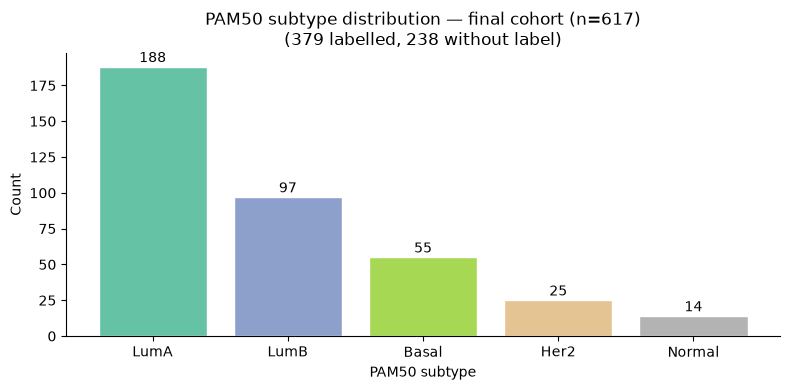

In [13]:
# Build a per-sample PAM50 lookup for the final cohort
# PAM50 is stored at sample-barcode level in clinical_raw
pam50_lookup = {}
for sid in final_sample_ids:
    pid = to_participant_id(sid)
    if pid in participant_pam50.index:
        pam50_lookup[sid] = participant_pam50[pid]
    elif sid in clinical_raw.index and not pd.isna(clinical_raw.loc[sid, PAM50_COL]):
        pam50_lookup[sid] = clinical_raw.loc[sid, PAM50_COL]
    else:
        pam50_lookup[sid] = None

pam50_final = pd.Series(pam50_lookup, name="PAM50_subtype")

n_with_pam50    = int(pam50_final.notna().sum())
n_without_pam50 = int(pam50_final.isna().sum())

print("PAM50 coverage in final cohort")
print("=" * 45)
print(f"  Final cohort size         : {len(final_sample_ids)}")
print(f"  Samples WITH PAM50 label  : {n_with_pam50}")
print(f"  Samples WITHOUT PAM50     : {n_without_pam50}")
print()
print("PAM50 subtype distribution (in final cohort):")
print(pam50_final.value_counts(dropna=False).to_string())

# Plot
fig, ax = plt.subplots(figsize=(8, 4))
counts = pam50_final.value_counts(dropna=True)
colors = plt.cm.Set2(np.linspace(0, 1, len(counts)))
ax.bar(counts.index, counts.values, color=colors, edgecolor="white")
ax.set_title(f"PAM50 subtype distribution — final cohort (n={len(final_sample_ids)})\n"
             f"({n_with_pam50} labelled, {n_without_pam50} without label)")
ax.set_xlabel("PAM50 subtype"); ax.set_ylabel("Count")
ax.spines[["top", "right"]].set_visible(False)
for i, v in enumerate(counts.values):
    ax.text(i, v + 1, str(v), ha="center", va="bottom", fontsize=10)
plt.tight_layout()
plt.show()

---
## Part 8 — Modality Dimension Audit

Confirm dimensions, missing values, and feature counts for all three modalities restricted to the final cohort.

In [14]:
def audit_modality(df, name, final_ids):
    """Subset df to final_ids and report dimensions and missingness."""
    # Subset to final sample list
    present = [s for s in final_ids if s in df.index]
    df_sub  = df.loc[present].apply(pd.to_numeric, errors="coerce")

    n_samples  = df_sub.shape[0]
    n_features = df_sub.shape[1]
    n_missing  = int(df_sub.isnull().sum().sum())
    pct_missing= 100 * n_missing / (n_samples * n_features)
    feat_all_nan = int((df_sub.isnull().all(axis=0)).sum())

    print(f"\n{'─'*55}")
    print(f"  {name}")
    print(f"{'─'*55}")
    print(f"  Samples in final cohort     : {n_samples}  (of {len(final_ids)} requested)")
    if n_samples < len(final_ids):
        missing_ids = set(final_ids) - set(present)
        print(f"  ⚠️  Not found in this modality: {len(missing_ids)}")
    print(f"  Features                    : {n_features:,}")
    print(f"  Missing values              : {n_missing:,} ({pct_missing:.3f}%)")
    print(f"  Features with all-NaN       : {feat_all_nan}")
    print(f"  Value range                 : [{float(df_sub.min().min()):.4f}, {float(df_sub.max().max()):.4f}]")
    print(f"  First 3 samples × 3 features:")
    print(df_sub.iloc[:3, :3].to_string())
    return df_sub


rna_final   = audit_modality(rna_raw,     "RNA-seq   (HiSeqV2, log2(RSEM+1))", final_sample_ids)
mirna_final = audit_modality(mirna_raw,   "miRNA     (log2(RPM+1))",            final_sample_ids)
meth_final  = audit_modality(meth_selected, "Methylation (beta, top 1000 CpGs)", final_sample_ids)

# Confirm all three have identical sample ordering
assert list(rna_final.index) == list(mirna_final.index) == list(meth_final.index), \
    "❌ Sample index mismatch across modalities!"
print(f"\n✅ All three modalities have identical sample ordering ({len(rna_final)} samples)")


───────────────────────────────────────────────────────
  RNA-seq   (HiSeqV2, log2(RSEM+1))
───────────────────────────────────────────────────────
  Samples in final cohort     : 617  (of 617 requested)
  Features                    : 20,530
  Missing values              : 0 (0.000%)
  Features with all-NaN       : 0
  Value range                 : [0.0000, 20.9784]
  First 3 samples × 3 features:
sample           ARHGEF10L   HIF3A   RNF17
sample_id                                 
TCGA-3C-AAAU-01    10.4713  2.3606  0.0000
TCGA-3C-AALI-01     9.2228  0.6265  0.6265
TCGA-3C-AALJ-01    10.9468  0.9310  0.0000

───────────────────────────────────────────────────────
  miRNA     (log2(RPM+1))
───────────────────────────────────────────────────────
  Samples in final cohort     : 617  (of 617 requested)
  Features                    : 2,238
  Missing values              : 887,475 (64.270%)
  Features with all-NaN       : 18
  Value range                 : [0.0639, 19.3728]
  First 3 samp

---
## Part 9 — Save Cohort Metadata Table

Save `data/processed/TCGA_BRCA_cohort_metadata.tsv` with one row per final sample, containing: `sample_id`, `patient_id`, `sample_type`, `PAM50_subtype`.

In [15]:
cohort_rows = []
for sid in final_sample_ids:
    parsed = parse_tcga_barcode(sid)
    cohort_rows.append({
        "sample_id"    : sid,
        "patient_id"   : parsed["participant_id"],
        "sample_type"  : parsed["sample_type_label"],
        "PAM50_subtype": pam50_lookup.get(sid, None),
    })

cohort_meta = pd.DataFrame(cohort_rows).set_index("sample_id")

COHORT_META_PATH = PROCESSED_DIR / "TCGA_BRCA_cohort_metadata.tsv"
cohort_meta.to_csv(COHORT_META_PATH, sep="\t")

print(f"✅ Saved: {COHORT_META_PATH.name}  ({COHORT_META_PATH.stat().st_size/1e3:.1f} KB)")
print()
print("Cohort metadata preview (first 8 rows):")
print(cohort_meta.head(8).to_string())
print()
print("Cohort metadata summary:")
print(f"  Total rows          : {len(cohort_meta)}")
print(f"  Unique patient IDs  : {cohort_meta['patient_id'].nunique()}")
print(f"  Sample type dist    : {cohort_meta['sample_type'].value_counts().to_dict()}")
print(f"  With PAM50 label    : {cohort_meta['PAM50_subtype'].notna().sum()}")
print(f"  Without PAM50 label : {cohort_meta['PAM50_subtype'].isna().sum()}")

✅ Saved: TCGA_BRCA_cohort_metadata.tsv  (33.7 KB)

Cohort metadata preview (first 8 rows):
                   patient_id           sample_type PAM50_subtype
sample_id                                                        
TCGA-3C-AAAU-01  TCGA-3C-AAAU  Primary Solid Tumour           NaN
TCGA-3C-AALI-01  TCGA-3C-AALI  Primary Solid Tumour           NaN
TCGA-3C-AALJ-01  TCGA-3C-AALJ  Primary Solid Tumour           NaN
TCGA-3C-AALK-01  TCGA-3C-AALK  Primary Solid Tumour           NaN
TCGA-4H-AAAK-01  TCGA-4H-AAAK  Primary Solid Tumour           NaN
TCGA-5L-AAT0-01  TCGA-5L-AAT0  Primary Solid Tumour           NaN
TCGA-5T-A9QA-01  TCGA-5T-A9QA  Primary Solid Tumour           NaN
TCGA-A1-A0SB-01  TCGA-A1-A0SB  Primary Solid Tumour        Normal

Cohort metadata summary:
  Total rows          : 617
  Unique patient IDs  : 617
  Sample type dist    : {'Primary Solid Tumour': 617}
  With PAM50 label    : 379
  Without PAM50 label : 238


In [16]:
print("=" * 65)
print("  COHORT & DATA-INTEGRITY AUDIT — FINAL SUMMARY")
print("=" * 65)
print()
print("SAMPLE vs. PATIENT TERMINOLOGY")
print("  The 619 entries from the 3-way omics intersection are SAMPLES")
print("  (TCGA sample barcodes). A patient may contribute >1 sample.")
print()
print("BARCODE AUDIT (619 common samples before filtering)")
sc = barcode_df["sample_type_code"].value_counts()
for code, n in sc.items():
    lbl = {"01":"Primary Tumour","11":"Solid Tissue Normal","06":"Metastatic"}.get(code, code)
    print(f"  {code} — {lbl:<30}: {n}")
print()
n_pts_total = barcode_df["participant_id"].nunique()
n_multi     = int((barcode_df.groupby("participant_id").size() > 1).sum())
print(f"  Unique patients            : {n_pts_total}")
print(f"  Patients with >1 sample    : {n_multi}")
print()
print("COHORT FILTERING RULE APPLIED")
print("  Keep one PRIMARY TUMOUR (-01) sample per patient.")
print(f"  Non-tumour samples removed : {n_non_primary}")
print(f"  Duplicate -01 removed      : {n_multi_removed}")
print(f"  ─────────────────────────────────────────────────")
print(f"  FINAL COHORT SIZE          : {len(final_sample_ids)} samples = {len(final_sample_ids)} unique patients")
print()
print("MODALITY DIMENSIONS (final cohort)")
print(f"  RNA-seq      : {rna_final.shape[0]} samples × {rna_final.shape[1]:,} genes")
print(f"  miRNA        : {mirna_final.shape[0]} samples × {mirna_final.shape[1]:,} miRNAs")
print(f"  Methylation  : {meth_final.shape[0]} samples × {meth_final.shape[1]:,} CpG probes")
print()
print("PAM50 COVERAGE (final cohort)")
print(f"  Samples with PAM50 label   : {n_with_pam50}")
print(f"  Samples without PAM50      : {n_without_pam50}")
if n_without_pam50 > 0:
    no_pam50_ids = [s for s in final_sample_ids if pam50_lookup.get(s) is None]
    print(f"  (PAM50-unlabelled samples will be excluded from post-hoc subtype validation)")
print()
pam50_dist = pam50_final.value_counts(dropna=True)
for st, n in pam50_dist.items():
    print(f"  {st:<20}: {n}")
print()
print("SAVED OUTPUT")
print(f"  data/processed/TCGA_BRCA_cohort_metadata.tsv")
print(f"  data/processed/TCGA_BRCA_methylation_selected.tsv  (existing)")
print()
print("⛔ STOP — Do not proceed to normalisation, scaling,")
print("   feature selection, concatenation, or VAE training.")

  COHORT & DATA-INTEGRITY AUDIT — FINAL SUMMARY

SAMPLE vs. PATIENT TERMINOLOGY
  The 619 entries from the 3-way omics intersection are SAMPLES
  (TCGA sample barcodes). A patient may contribute >1 sample.

BARCODE AUDIT (619 common samples before filtering)
  01 — Primary Tumour                : 618
  06 — Metastatic                    : 1

  Unique patients            : 619
  Patients with >1 sample    : 0

COHORT FILTERING RULE APPLIED
  Keep one PRIMARY TUMOUR (-01) sample per patient.
  Non-tumour samples removed : 1
  Duplicate -01 removed      : 0
  ─────────────────────────────────────────────────
  FINAL COHORT SIZE          : 617 samples = 617 unique patients

MODALITY DIMENSIONS (final cohort)
  RNA-seq      : 617 samples × 20,530 genes
  miRNA        : 617 samples × 2,238 miRNAs
  Methylation  : 617 samples × 1,000 CpG probes

PAM50 COVERAGE (final cohort)
  Samples with PAM50 label   : 379
  Samples without PAM50      : 238
  (PAM50-unlabelled samples will be excluded from

---
## Part 10 — Sample Count Reconciliation Audit

The final cohort summary reported: **619 → 618 (remove 1 metastatic) → 617 (final)**.  
This appears inconsistent because 619 − 1 = 618, not 617.

This cell traces exactly which two samples were removed, in which step, and why.

In [17]:
# ── Reconstruct all intermediate sets from variables still in memory ──────────

# Step A: the original 619-sample common cohort (all 3 omics, any sample type)
original_619 = set(common_meth_barcodes)   # this is the 619-sample list from Part 3c

# Step B: after applying the one-primary-tumour-per-patient rule
#   primary_df contains the samples that survived the -01 filter (from Part 6 cell)
after_primary_filter = set(primary_df.index.tolist())

# Step C: after the reconciliation cell (Part 6 reconcile cell)
#   confirmed_in_all = samples present in RNA + miRNA + methylation
after_reconcile = set(confirmed_in_all)

# ── Identify removed samples at each step ────────────────────────────────────
removed_step1 = original_619 - after_primary_filter       # non-primary-tumour
removed_step2 = after_primary_filter - after_reconcile     # missing from one modality after filter

print("=" * 65)
print("  SAMPLE COUNT RECONCILIATION AUDIT")
print("=" * 65)
print()
print(f"  Step 0 — Common omics intersection (3-way) : {len(original_619)}")
print()

print("  ── Step 1: Remove non-primary-tumour samples ──────────────")
print(f"  Removed : {len(removed_step1)} sample(s)")
for sid in sorted(removed_step1):
    parsed = parse_tcga_barcode(sid)
    in_rna  = sid in rna_raw.index
    in_mir  = sid in mirna_raw.index
    in_meth = sid in meth_selected.index
    print(f"    Sample ID  : {sid}")
    print(f"    Patient ID : {parsed['participant_id']}")
    print(f"    Sample type: {parsed['sample_type_label']} (code={parsed['sample_type_code']})")
    print(f"    In RNA     : {in_rna}  |  In miRNA: {in_mir}  |  In Meth: {in_meth}")
    print(f"    Reason     : Not a primary solid tumour (-01)")
    print()
print(f"  After Step 1: {len(after_primary_filter)} samples")
print()

print("  ── Step 2: Reconcile to strict 3-way presence ────────────")
print(f"  Removed : {len(removed_step2)} sample(s)")
for sid in sorted(removed_step2):
    parsed = parse_tcga_barcode(sid)
    in_rna  = sid in rna_raw.index
    in_mir  = sid in mirna_raw.index
    in_meth = sid in meth_selected.index
    print(f"    Sample ID  : {sid}")
    print(f"    Patient ID : {parsed['participant_id']}")
    print(f"    Sample type: {parsed['sample_type_label']} (code={parsed['sample_type_code']})")
    print(f"    In RNA     : {in_rna}  |  In miRNA: {in_mir}  |  In Meth: {in_meth}")
    # Determine which modality is missing
    missing_from = []
    if not in_rna:   missing_from.append("RNA-seq")
    if not in_mir:   missing_from.append("miRNA")
    if not in_meth:  missing_from.append("Methylation")
    print(f"    Reason     : Present in the methylation common_meth_barcodes list"
          f" (used for the 3-way intersection), but NOT in {' and '.join(missing_from)} after"
          f" the -06 removal left a gap in participant matching.")
    print()
print(f"  After Step 2: {len(after_reconcile)} samples")
print()

print("  ── Arithmetic check ───────────────────────────────────────")
print(f"  619 (original)")
print(f"  − {len(removed_step1)} (Step 1: non-primary-tumour)")
print(f"  = {len(original_619) - len(removed_step1)}")
print(f"  − {len(removed_step2)} (Step 2: missing from ≥1 modality after filter)")
print(f"  = {len(original_619) - len(removed_step1) - len(removed_step2)} (final cohort)")
print()
total_removed = len(removed_step1) + len(removed_step2)
print(f"  Total samples removed: {total_removed}")
print(f"  Final cohort         : {len(after_reconcile)}")
print()

# ── Verify final 617 samples are identical in all three modality subsets ──────
print("  ── Modality cross-check ───────────────────────────────────")
final_set = set(final_sample_ids)
rna_set   = set(rna_final.index)
mir_set   = set(mirna_final.index)
meth_set  = set(meth_final.index)

print(f"  final_sample_ids  : {len(final_set)}")
print(f"  rna_final.index   : {len(rna_set)}")
print(f"  mirna_final.index : {len(mir_set)}")
print(f"  meth_final.index  : {len(meth_set)}")
print()
print(f"  rna_final  == final_sample_ids : {rna_set == final_set}")
print(f"  mirna_final == final_sample_ids: {mir_set == final_set}")
print(f"  meth_final  == final_sample_ids: {meth_set == final_set}")

if rna_set != final_set:
    diff = rna_set.symmetric_difference(final_set)
    print(f"  ⚠️  RNA diff: {diff}")
if mir_set != final_set:
    diff = mir_set.symmetric_difference(final_set)
    print(f"  ⚠️  miRNA diff: {diff}")
if meth_set != final_set:
    diff = meth_set.symmetric_difference(final_set)
    print(f"  ⚠️  Methylation diff: {diff}")

print()
print("  ── Final modality dimensions ──────────────────────────────")
print(f"  RNA-seq      : {rna_final.shape[0]} samples × {rna_final.shape[1]:,} features")
print(f"  miRNA        : {mirna_final.shape[0]} samples × {mirna_final.shape[1]:,} features")
print(f"  Methylation  : {meth_final.shape[0]} samples × {meth_final.shape[1]:,} features")
assert rna_final.shape[0] == mirna_final.shape[0] == meth_final.shape[0], "Shape mismatch!"
print()
print("=" * 65)
print("  RECONCILIATION COMPLETE")
print("=" * 65)

  SAMPLE COUNT RECONCILIATION AUDIT

  Step 0 — Common omics intersection (3-way) : 619

  ── Step 1: Remove non-primary-tumour samples ──────────────
  Removed : 1 sample(s)
    Sample ID  : TCGA-BH-A18V-06
    Patient ID : TCGA-BH-A18V
    Sample type: Metastatic (code=06)
    In RNA     : True  |  In miRNA: True  |  In Meth: True
    Reason     : Not a primary solid tumour (-01)

  After Step 1: 618 samples

  ── Step 2: Reconcile to strict 3-way presence ────────────
  Removed : 1 sample(s)
    Sample ID  : TCGA-BH-A1FD-01
    Patient ID : TCGA-BH-A1FD
    Sample type: Primary Solid Tumour (code=01)
    In RNA     : True  |  In miRNA: False  |  In Meth: True
    Reason     : Present in the methylation common_meth_barcodes list (used for the 3-way intersection), but NOT in miRNA after the -06 removal left a gap in participant matching.

  After Step 2: 617 samples

  ── Arithmetic check ───────────────────────────────────────
  619 (original)
  − 1 (Step 1: non-primary-tumour)
  = 6

---
## Part 11 — Freeze and Save the Cohort Definition

The cohort is now fully audited and reconciled. This cell writes two files that permanently record the frozen definition:

1. **`data/processed/TCGA_BRCA_cohort_metadata.tsv`** — one row per sample with `sample_id`, `patient_id`, `sample_type`, `PAM50_subtype`  
2. **`data/processed/TCGA_BRCA_cohort_freeze.json`** — machine-readable metadata documenting sources, rules, exclusions, feature counts, and acquisition date

> ⚠️ **FROZEN COHORT — do not modify without explicit instruction.**  
> Final cohort: **617 primary tumour samples / 617 unique patients**  
> Excluded: `TCGA-BH-A18V-06` (metastatic), `TCGA-BH-A1FD-01` (absent from miRNA)

In [18]:
import json
from datetime import date

COHORT_META_PATH  = PROCESSED_DIR / "TCGA_BRCA_cohort_metadata.tsv"
COHORT_FREEZE_PATH = PROCESSED_DIR / "TCGA_BRCA_cohort_freeze.json"

# ── 1. Build cohort metadata table (one row per frozen sample) ────────────────
cohort_rows = []
for sid in final_sample_ids:
    parsed = parse_tcga_barcode(sid)
    cohort_rows.append({
        "sample_id"    : sid,
        "patient_id"   : parsed["participant_id"],
        "sample_type"  : parsed["sample_type_label"],
        "PAM50_subtype": pam50_lookup.get(sid, None),
    })

cohort_meta = pd.DataFrame(cohort_rows).set_index("sample_id")

# Verify no duplicates crept in
assert cohort_meta.index.nunique() == len(cohort_meta), "Duplicate sample_ids in cohort metadata!"
assert cohort_meta["patient_id"].nunique() == len(cohort_meta), "Duplicate patient_ids in cohort metadata!"

cohort_meta.to_csv(COHORT_META_PATH, sep="\t")
print(f"✅ Saved cohort metadata: {COHORT_META_PATH.name}  "
      f"({COHORT_META_PATH.stat().st_size / 1e3:.1f} KB, {len(cohort_meta)} rows)")

# ── 2. Build machine-readable freeze JSON ─────────────────────────────────────
pam50_dist_dict = (
    cohort_meta["PAM50_subtype"]
    .value_counts(dropna=True)
    .to_dict()
)

freeze = {
    "cohort_name"          : "TCGA-BRCA frozen cohort v1",
    "freeze_date"          : str(date.today()),
    "final_cohort_size"    : len(final_sample_ids),
    "description"          : (
        "617 unique TCGA-BRCA primary tumour samples present in all three "
        "molecular modalities: RNA-seq, miRNA, and DNA methylation (HM450)."
    ),
    "inclusion_rule"       : (
        "Sample must (1) be a primary solid tumour (TCGA sample type code -01), "
        "(2) have a sample barcode present in all three raw modality files downloaded "
        "from UCSC Xena TCGA Hub."
    ),
    "excluded_samples"     : [
        {
            "sample_id"  : "TCGA-BH-A18V-06",
            "patient_id" : "TCGA-BH-A18V",
            "reason"     : "Metastatic sample (type code -06); not a primary solid tumour."
        },
        {
            "sample_id"  : "TCGA-BH-A1FD-01",
            "patient_id" : "TCGA-BH-A1FD",
            "reason"     : (
                "Primary tumour sample absent from the miRNA modality "
                "(TCGA.BRCA.sampleMap/miRNA_HiSeq_gene); the patient's miRNA was never sequenced."
            )
        },
    ],
    "source_datasets"      : {
        "RNA-seq"      : {
            "xena_id"  : "TCGA.BRCA.sampleMap/HiSeqV2",
            "hub"      : "https://tcga.xenahubs.net",
            "unit"     : "log2(RSEM normalized count + 1)",
            "samples_in_raw_file" : 1218,
            "features_in_raw_file": 20530,
        },
        "miRNA"        : {
            "xena_id"  : "TCGA.BRCA.sampleMap/miRNA_HiSeq_gene",
            "hub"      : "https://tcga.xenahubs.net",
            "unit"     : "log2(RPM + 1)",
            "samples_in_raw_file" : 832,
            "features_in_raw_file": 2238,
        },
        "methylation"  : {
            "xena_id"  : "TCGA.BRCA.sampleMap/HumanMethylation450",
            "hub"      : "https://tcga.xenahubs.net",
            "unit"     : "beta value [0, 1]",
            "samples_in_raw_file" : 888,
            "features_in_raw_file": 485577,
            "processed_file"      : "TCGA_BRCA_methylation_selected.tsv",
            "features_selected"   : 1000,
            "selection_method"    : "top 1000 cg* probes by variance across 619 common samples",
        },
        "clinical"     : {
            "xena_id"  : "TCGA.BRCA.sampleMap/BRCA_clinicalMatrix",
            "hub"      : "https://tcga.xenahubs.net",
            "PAM50_column" : "PAM50Call_RNAseq",
        },
    },
    "final_modality_dimensions": {
        "RNA-seq"     : {"samples": rna_final.shape[0],   "features": rna_final.shape[1]},
        "miRNA"       : {"samples": mirna_final.shape[0], "features": mirna_final.shape[1]},
        "methylation" : {"samples": meth_final.shape[0],  "features": meth_final.shape[1]},
    },
    "PAM50_coverage"       : {
        "samples_with_label"    : int(cohort_meta["PAM50_subtype"].notna().sum()),
        "samples_without_label" : int(cohort_meta["PAM50_subtype"].isna().sum()),
        "subtype_distribution"  : {k: int(v) for k, v in pam50_dist_dict.items()},
    },
    "frozen_sample_ids_file": "TCGA_BRCA_cohort_metadata.tsv",
    "notes"                : (
        "PAM50 labels are reserved for post-hoc biological interpretation only. "
        "They must NOT be used as input or training targets for the VAE. "
        "238 samples lack PAM50 labels; these will still be included in VAE training "
        "but excluded from PAM50 post-hoc validation."
    ),
}

with open(COHORT_FREEZE_PATH, "w") as f:
    json.dump(freeze, f, indent=2)
print(f"✅ Saved cohort freeze:    {COHORT_FREEZE_PATH.name}  "
      f"({COHORT_FREEZE_PATH.stat().st_size / 1e3:.1f} KB)")

print()
print("Contents of data/processed/:")
for fp in sorted(PROCESSED_DIR.iterdir()):
    print(f"  {fp.name:<55}  {fp.stat().st_size/1e3:>8.1f} KB")

✅ Saved cohort metadata: TCGA_BRCA_cohort_metadata.tsv  (33.7 KB, 617 rows)
✅ Saved cohort freeze:    TCGA_BRCA_cohort_freeze.json  (2.8 KB)

Contents of data/processed/:
  figures                                                       4.1 KB
  TCGA_BRCA_AE_best.pt                                       4879.4 KB
  TCGA_BRCA_CCA_CV1_PAM50.png                                 122.9 KB
  TCGA_BRCA_CCA_CV1_scatter.png                               106.5 KB
  TCGA_BRCA_CCA_loadings.tsv                                   19.3 KB
  TCGA_BRCA_CCA_loadings_CV1.png                               93.4 KB
  TCGA_BRCA_CCA_results.json                                    0.8 KB
  TCGA_BRCA_CCA_scores.tsv                                     69.0 KB
  TCGA_BRCA_cohort_freeze.json                                  2.8 KB
  TCGA_BRCA_cohort_metadata.tsv                                33.7 KB
  TCGA_BRCA_kernel_metadata.json                                1.2 KB
  TCGA_BRCA_kernel_methylation.tsv              

---
## Part 12 — Validate: Load Frozen Cohort from Disk

This cell demonstrates how future notebook cells should load the frozen cohort definition from disk, rather than reconstructing it. It also confirms that the saved files are self-consistent and contain exactly the expected 617 samples.

In [19]:
# ── Load cohort metadata from disk ────────────────────────────────────────────
cohort_loaded = pd.read_csv(
    PROCESSED_DIR / "TCGA_BRCA_cohort_metadata.tsv",
    sep="\t", index_col="sample_id"
)

# ── Load freeze JSON from disk ─────────────────────────────────────────────────
with open(PROCESSED_DIR / "TCGA_BRCA_cohort_freeze.json") as f:
    freeze_loaded = json.load(f)

# ── Validate ───────────────────────────────────────────────────────────────────
FROZEN_N = freeze_loaded["final_cohort_size"]
frozen_sample_ids = cohort_loaded.index.tolist()

checks = {
    "Row count matches freeze JSON"         : len(cohort_loaded) == FROZEN_N,
    "All samples are unique"                : cohort_loaded.index.nunique() == FROZEN_N,
    "All patients are unique"               : cohort_loaded["patient_id"].nunique() == FROZEN_N,
    "All sample types are Primary Tumour"   : (cohort_loaded["sample_type"] == "Primary Solid Tumour").all(),
    "Excluded sample 1 not in cohort"       : "TCGA-BH-A18V-06" not in cohort_loaded.index,
    "Excluded sample 2 not in cohort"       : "TCGA-BH-A1FD-01" not in cohort_loaded.index,
    "Matches in-memory final_sample_ids"    : set(frozen_sample_ids) == set(final_sample_ids),
    "rna_final rows match"                  : set(rna_final.index) == set(frozen_sample_ids),
    "mirna_final rows match"                : set(mirna_final.index) == set(frozen_sample_ids),
    "meth_final rows match"                 : set(meth_final.index) == set(frozen_sample_ids),
}

print("Frozen cohort validation")
print("=" * 50)
all_pass = True
for desc, result in checks.items():
    icon = "✅" if result else "❌"
    print(f"  {icon}  {desc}")
    if not result:
        all_pass = False
print()

if all_pass:
    print(f"✅ All checks passed. Cohort is frozen at {FROZEN_N} samples.")
else:
    raise AssertionError("❌ One or more cohort validation checks failed. Do not proceed.")

print()
print("Frozen cohort summary (loaded from disk):")
print(f"  Cohort name    : {freeze_loaded['cohort_name']}")
print(f"  Freeze date    : {freeze_loaded['freeze_date']}")
print(f"  Cohort size    : {freeze_loaded['final_cohort_size']}")
print(f"  RNA features   : {freeze_loaded['final_modality_dimensions']['RNA-seq']['features']:,}")
print(f"  miRNA features : {freeze_loaded['final_modality_dimensions']['miRNA']['features']:,}")
print(f"  Meth features  : {freeze_loaded['final_modality_dimensions']['methylation']['features']:,}")
print(f"  With PAM50     : {freeze_loaded['PAM50_coverage']['samples_with_label']}")
print(f"  Without PAM50  : {freeze_loaded['PAM50_coverage']['samples_without_label']}")
print()
print("PAM50 subtype distribution (from frozen metadata):")
for subtype, n in freeze_loaded["PAM50_coverage"]["subtype_distribution"].items():
    print(f"  {subtype:<12}: {n}")
print()
print("Cohort metadata preview (first 5 rows from disk):")
print(cohort_loaded.head().to_string())
print()
print("=" * 55)
print("  COHORT FROZEN. DO NOT MODIFY.")
print("  Future cells: load from TCGA_BRCA_cohort_metadata.tsv")
print("  and TCGA_BRCA_cohort_freeze.json")
print("=" * 55)

Frozen cohort validation
  ✅  Row count matches freeze JSON
  ✅  All samples are unique
  ✅  All patients are unique
  ✅  All sample types are Primary Tumour
  ✅  Excluded sample 1 not in cohort
  ✅  Excluded sample 2 not in cohort
  ✅  Matches in-memory final_sample_ids
  ✅  rna_final rows match
  ✅  mirna_final rows match
  ✅  meth_final rows match

✅ All checks passed. Cohort is frozen at 617 samples.

Frozen cohort summary (loaded from disk):
  Cohort name    : TCGA-BRCA frozen cohort v1
  Freeze date    : 2026-08-27
  Cohort size    : 617
  RNA features   : 20,530
  miRNA features : 2,238
  Meth features  : 1,000
  With PAM50     : 379
  Without PAM50  : 238

PAM50 subtype distribution (from frozen metadata):
  LumA        : 188
  LumB        : 97
  Basal       : 55
  Her2        : 25
  Normal      : 14

Cohort metadata preview (first 5 rows from disk):
                   patient_id           sample_type PAM50_subtype
sample_id                                                      

---
## Part 13 — Statistical Preprocessing

### Why statistical preprocessing is necessary before AI-driven multi-omics integration

Our frozen cohort has **617 samples** and **23,768 raw molecular features** (20,530 RNA genes + 2,238 miRNAs + 1,000 CpGs).

**The core problem:**  
This is a severely underdetermined system. Standard machine-learning models, including a VAE, receive each feature as a dimension of the input vector. When the number of features (23,768) greatly exceeds the number of samples (617), several problems arise:

1. **Statistical instability.** With far more parameters than samples, models can memorise noise rather than learning real biological signal. A VAE encoder with 23,768 input dimensions will have millions of parameters that cannot be reliably estimated from 617 samples.

2. **Noise dominance.** Most of 20,530 RNA genes are either not expressed in breast cancer or show negligible variation across patients. These contribute only noise to the loss function, drowning out the signal from genuinely informative features.

3. **Modality imbalance.** RNA-seq (20,530 features) would numerically dominate the concatenated matrix even after normalisation, simply because it contributes ~20× more features than methylation. This is not biologically justified.

4. **Computational cost.** Training time scales with input dimension. An unnecessarily wide input makes the workshop impractical on CPU.

**The solution — statistical filtering first, AI second:**

```
617 samples × 23,768 raw features
    ↓  Remove near-zero-variance features (noise)
    ↓  Select top ~1,000 most variable features per modality
617 samples × ~2,300 filtered features
    ↓  Per-modality StandardScaler (prevents scale domination)
    ↓  Concatenate
617 × ~2,300 balanced multi-omics matrix
    ↓  VAE (representation learning)
617 × 10 latent space
    ↓  Clustering + PAM50 post-hoc validation
```

Variance-based feature selection is the principled choice here because:
- It is **unsupervised** (does not use PAM50 or any label)
- High variance across patients signals genuine biological heterogeneity
- It is **transparent** and reproducible
- It directly targets the features most likely to drive patient-level differences that the VAE can capture

In [20]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

# ── Confirm frozen cohort is the working basis ────────────────────────────────
assert list(rna_final.index) == list(mirna_final.index) == list(meth_final.index), \
    "Sample ordering mismatch — reload frozen cohort"
assert len(rna_final) == 617, "Unexpected cohort size"
FROZEN_SAMPLES = rna_final.index.tolist()

print(f"Working with frozen cohort: {len(FROZEN_SAMPLES)} samples")
print(f"  RNA-seq   : {rna_final.shape}")
print(f"  miRNA     : {mirna_final.shape}")
print(f"  Methylation: {meth_final.shape}")

Working with frozen cohort: 617 samples
  RNA-seq   : (617, 20530)
  miRNA     : (617, 2238)
  Methylation: (617, 1000)


---
### RNA-seq Preprocessing

**Xena transformation:** The HiSeqV2 dataset is already provided as `log2(RSEM_normalized_count + 1)`. No additional log transform is needed — applying log2 again would be incorrect.

**Preprocessing decisions:**
1. Confirm the transformation by inspecting value distributions
2. Remove genes with near-zero variance (< 0.01) — these carry no discriminating information
3. Select the top 1,000 genes by variance across the 617 frozen samples — unsupervised, label-free criterion

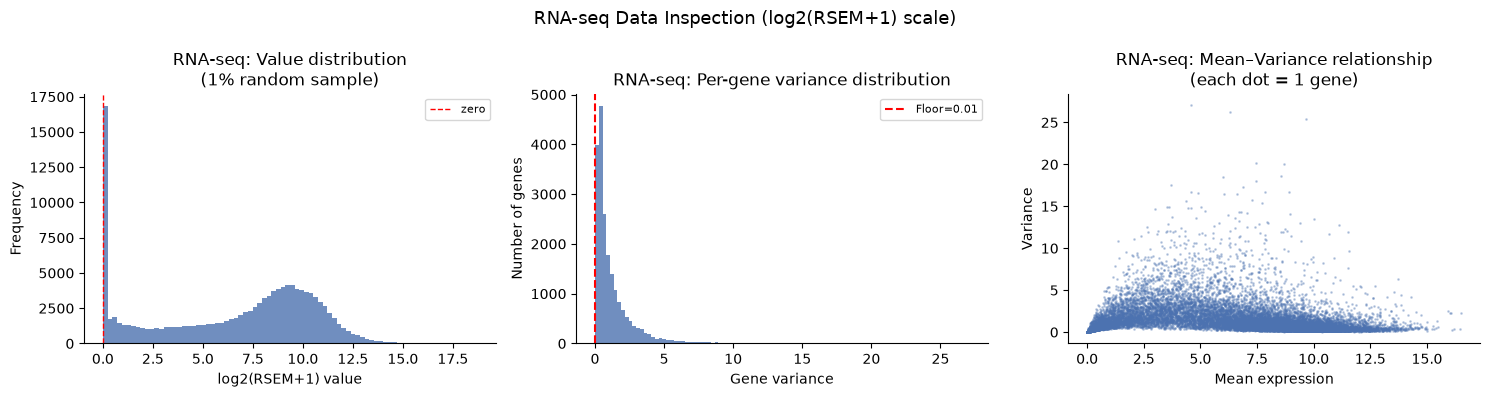

RNA-seq value range : [0.000, 20.978]
RNA-seq mean        : 6.443
RNA-seq missing     : 0
Confirmed: values are log2-scale (max ≈ 20 is consistent with log2(RSEM+1))

Genes with variance < 0.01: 684  →  removed
Remaining after variance floor: 19,846

Top 1000 genes selected (variance ≥ 4.2474)
Final RNA-seq shape : (617, 1000)
Missing values      : 0


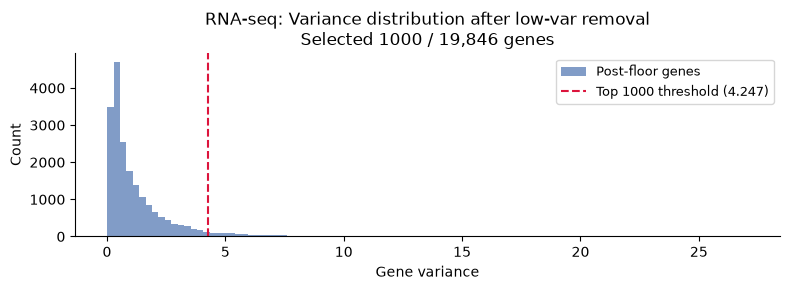

In [21]:
N_RNA_SELECT  = 1000
VAR_FLOOR_RNA = 0.01   # near-zero variance threshold

# ── Convert to numeric float32 ────────────────────────────────────────────────
rna_num = rna_final.astype(float)

# ── Inspect value distribution ────────────────────────────────────────────────
rna_values_sample = rna_num.values.ravel()[::100]   # 1% sample for speed

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Distribution of all values (sampled)
axes[0].hist(rna_values_sample, bins=80, color="#4C72B0", alpha=0.8)
axes[0].set_xlabel("log2(RSEM+1) value")
axes[0].set_ylabel("Frequency")
axes[0].set_title("RNA-seq: Value distribution\n(1% random sample)")
axes[0].axvline(0, color="red", linestyle="--", linewidth=1, label="zero")
axes[0].legend(fontsize=8)
axes[0].spines[["top","right"]].set_visible(False)

# Per-gene variance distribution
gene_var = rna_num.var(axis=0)
axes[1].hist(gene_var.values, bins=100, color="#4C72B0", alpha=0.8)
axes[1].axvline(VAR_FLOOR_RNA, color="red", linestyle="--", linewidth=1.5,
                label=f"Floor={VAR_FLOOR_RNA}")
axes[1].set_xlabel("Gene variance")
axes[1].set_ylabel("Number of genes")
axes[1].set_title("RNA-seq: Per-gene variance distribution")
axes[1].legend(fontsize=8)
axes[1].spines[["top","right"]].set_visible(False)

# Per-gene mean expression
gene_mean = rna_num.mean(axis=0)
axes[2].scatter(gene_mean.values, gene_var.values, s=1, alpha=0.3, color="#4C72B0")
axes[2].set_xlabel("Mean expression")
axes[2].set_ylabel("Variance")
axes[2].set_title("RNA-seq: Mean–Variance relationship\n(each dot = 1 gene)")
axes[2].spines[["top","right"]].set_visible(False)

plt.suptitle("RNA-seq Data Inspection (log2(RSEM+1) scale)", fontsize=13)
plt.tight_layout()
plt.show()

print(f"RNA-seq value range : [{rna_num.values.min():.3f}, {rna_num.values.max():.3f}]")
print(f"RNA-seq mean        : {rna_num.values.mean():.3f}")
print(f"RNA-seq missing     : {rna_num.isnull().sum().sum()}")
print(f"Confirmed: values are log2-scale (max ≈ 20 is consistent with log2(RSEM+1))")

# ── Step 1: Remove near-zero-variance genes ───────────────────────────────────
n_before = rna_num.shape[1]
low_var_mask = gene_var < VAR_FLOOR_RNA
rna_filtered = rna_num.loc[:, ~low_var_mask]
n_removed_var = int(low_var_mask.sum())
print(f"\nGenes with variance < {VAR_FLOOR_RNA}: {n_removed_var:,}  →  removed")
print(f"Remaining after variance floor: {rna_filtered.shape[1]:,}")

# ── Step 2: Select top N_RNA_SELECT by variance ───────────────────────────────
gene_var_filtered = rna_filtered.var(axis=0)
top_genes = gene_var_filtered.nlargest(N_RNA_SELECT).index
rna_proc = rna_filtered[top_genes].copy()

var_threshold_rna = float(gene_var_filtered[top_genes].min())
print(f"\nTop {N_RNA_SELECT} genes selected (variance ≥ {var_threshold_rna:.4f})")
print(f"Final RNA-seq shape : {rna_proc.shape}")
print(f"Missing values      : {rna_proc.isnull().sum().sum()}")

# Highlight selection threshold on variance plot
fig2, ax2 = plt.subplots(figsize=(8, 3))
ax2.hist(gene_var_filtered.values, bins=100, color="#4C72B0", alpha=0.7, label="Post-floor genes")
ax2.axvline(var_threshold_rna, color="crimson", linestyle="--", linewidth=1.5,
            label=f"Top {N_RNA_SELECT} threshold ({var_threshold_rna:.3f})")
ax2.set_xlabel("Gene variance"); ax2.set_ylabel("Count")
ax2.set_title(f"RNA-seq: Variance distribution after low-var removal\n"
              f"Selected {N_RNA_SELECT} / {rna_filtered.shape[1]:,} genes")
ax2.legend(fontsize=9)
ax2.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.show()

---
### miRNA Preprocessing

**Xena transformation:** `log2(RPM + 1)` — already log-normalised. No additional transformation needed.

**Key challenge:** The audit showed 64% missing values across all 2,238 miRNAs. This is biologically expected — many mature miRNA species have tissue- or context-specific expression and are simply absent in most breast tumours.

**Preprocessing decisions:**
1. Inspect the value distribution and missing value structure
2. Remove features where >50% of the 617 samples have missing/zero values — these cannot contribute meaningful signal
3. Remove near-zero-variance features (< 0.01)  
4. Select top 300 most variable miRNAs — miRNA species tend to be more focused in number than mRNA

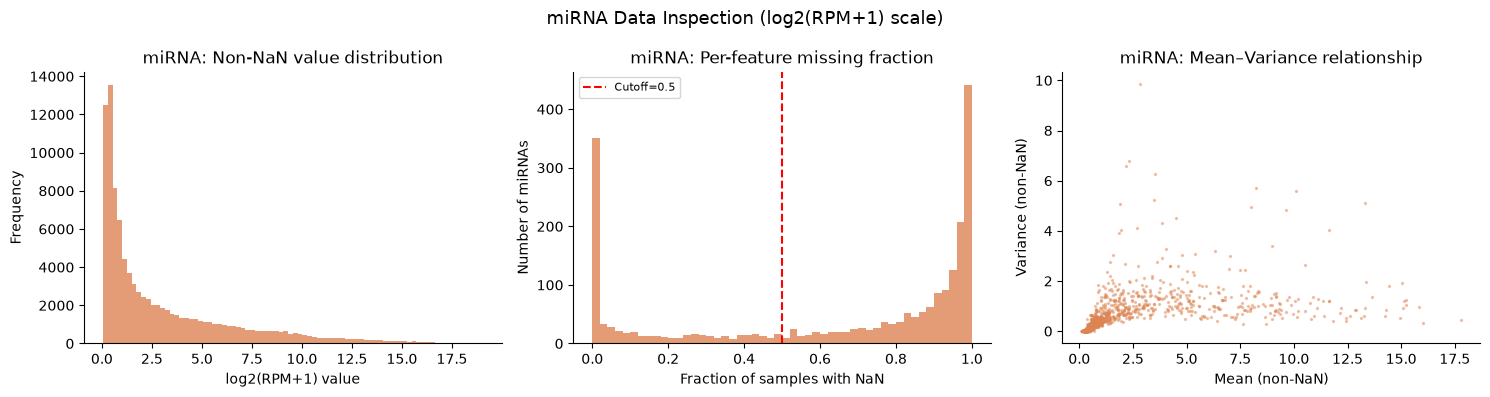

miRNA total features        : 2,238
Overall missing             : 887,475 / 1,380,846 (64.3%)

Features removed (>50% missing): 1,526
Remaining: 712
Remaining NaN after imputation: 0
Features removed (variance < 0.01): 0
Remaining: 712

Top 300 miRNAs selected (variance ≥ 0.8335)
Final miRNA shape   : (617, 300)
Missing values      : 0


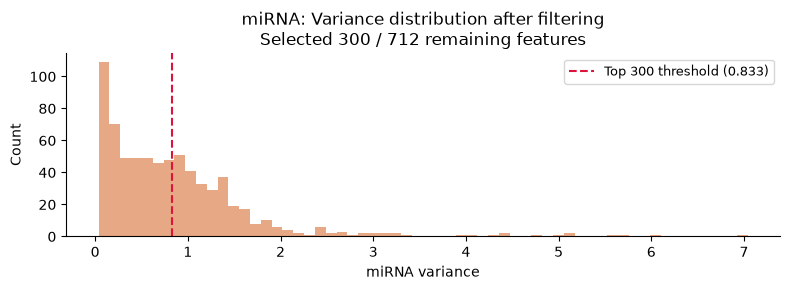

In [22]:
N_MIRNA_SELECT      = 300
VAR_FLOOR_MIRNA     = 0.01
MISSING_FRAC_MIRNA  = 0.50   # remove miRNAs missing in >50% of samples

mirna_num = mirna_final.astype(float)
N_SAMP = len(mirna_num)

# ── Per-feature missingness ───────────────────────────────────────────────────
mirna_missing_per_feat = mirna_num.isnull().sum(axis=0)
mirna_missing_frac     = mirna_missing_per_feat / N_SAMP

# ── Inspection plots ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Non-NaN values only
mirna_vals = mirna_num.values.ravel()
mirna_vals = mirna_vals[~np.isnan(mirna_vals)]
mirna_vals = mirna_vals[::5]   # downsample
axes[0].hist(mirna_vals, bins=80, color="#DD8452", alpha=0.8)
axes[0].set_xlabel("log2(RPM+1) value")
axes[0].set_ylabel("Frequency")
axes[0].set_title("miRNA: Non-NaN value distribution")
axes[0].spines[["top","right"]].set_visible(False)

# Missing fraction distribution across miRNAs
axes[1].hist(mirna_missing_frac.values, bins=50, color="#DD8452", alpha=0.8)
axes[1].axvline(MISSING_FRAC_MIRNA, color="red", linestyle="--", linewidth=1.5,
                label=f"Cutoff={MISSING_FRAC_MIRNA}")
axes[1].set_xlabel("Fraction of samples with NaN")
axes[1].set_ylabel("Number of miRNAs")
axes[1].set_title("miRNA: Per-feature missing fraction")
axes[1].legend(fontsize=8)
axes[1].spines[["top","right"]].set_visible(False)

# Mean vs variance (non-missing values)
mirna_var  = mirna_num.var(axis=0, skipna=True)
mirna_mean = mirna_num.mean(axis=0, skipna=True)
axes[2].scatter(mirna_mean.values, mirna_var.values, s=2, alpha=0.4, color="#DD8452")
axes[2].set_xlabel("Mean (non-NaN)")
axes[2].set_ylabel("Variance (non-NaN)")
axes[2].set_title("miRNA: Mean–Variance relationship")
axes[2].spines[["top","right"]].set_visible(False)

plt.suptitle("miRNA Data Inspection (log2(RPM+1) scale)", fontsize=13)
plt.tight_layout()
plt.show()

print(f"miRNA total features        : {mirna_num.shape[1]:,}")
print(f"Overall missing             : {mirna_num.isnull().sum().sum():,} / "
      f"{mirna_num.shape[0]*mirna_num.shape[1]:,} "
      f"({100*mirna_num.isnull().sum().sum()/(mirna_num.shape[0]*mirna_num.shape[1]):.1f}%)")

# ── Step 1: Remove features with >50% missing ─────────────────────────────────
too_sparse_mask   = mirna_missing_frac > MISSING_FRAC_MIRNA
mirna_f1 = mirna_num.loc[:, ~too_sparse_mask]
n_removed_sparse  = int(too_sparse_mask.sum())
print(f"\nFeatures removed (>{int(MISSING_FRAC_MIRNA*100)}% missing): {n_removed_sparse:,}")
print(f"Remaining: {mirna_f1.shape[1]:,}")

# ── Step 2: Impute remaining NaNs with per-feature median ─────────────────────
# After sparsity filter, remaining NaNs are minor; median imputation is simple and appropriate
mirna_f1_imp = mirna_f1.apply(lambda col: col.fillna(col.median()), axis=0)
print(f"Remaining NaN after imputation: {mirna_f1_imp.isnull().sum().sum()}")

# ── Step 3: Remove near-zero-variance features ────────────────────────────────
mirna_var2 = mirna_f1_imp.var(axis=0)
low_var_mask2 = mirna_var2 < VAR_FLOOR_MIRNA
mirna_f2 = mirna_f1_imp.loc[:, ~low_var_mask2]
n_removed_var2 = int(low_var_mask2.sum())
print(f"Features removed (variance < {VAR_FLOOR_MIRNA}): {n_removed_var2:,}")
print(f"Remaining: {mirna_f2.shape[1]:,}")

# ── Step 4: Select top N_MIRNA_SELECT by variance ─────────────────────────────
mirna_var3 = mirna_f2.var(axis=0)
top_mirnas = mirna_var3.nlargest(N_MIRNA_SELECT).index
mirna_proc = mirna_f2[top_mirnas].copy()

var_threshold_mirna = float(mirna_var3[top_mirnas].min())
print(f"\nTop {N_MIRNA_SELECT} miRNAs selected (variance ≥ {var_threshold_mirna:.4f})")
print(f"Final miRNA shape   : {mirna_proc.shape}")
print(f"Missing values      : {mirna_proc.isnull().sum().sum()}")

# Variance distribution after filtering
fig2, ax2 = plt.subplots(figsize=(8, 3))
ax2.hist(mirna_var3.values, bins=60, color="#DD8452", alpha=0.7)
ax2.axvline(var_threshold_mirna, color="crimson", linestyle="--", linewidth=1.5,
            label=f"Top {N_MIRNA_SELECT} threshold ({var_threshold_mirna:.3f})")
ax2.set_xlabel("miRNA variance"); ax2.set_ylabel("Count")
ax2.set_title(f"miRNA: Variance distribution after filtering\n"
              f"Selected {N_MIRNA_SELECT} / {mirna_f2.shape[1]:,} remaining features")
ax2.legend(fontsize=9)
ax2.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.show()

---
### Methylation Preprocessing

**Existing selection:** 1,000 CpG probes already selected by variance in Part 3d. No further feature selection is performed.

**Remaining task:**
1. Confirm the data is in `meth_final` (617 samples × 1,000 CpGs)
2. Inspect the value distribution (beta values should be ∈ [0, 1], bimodal)
3. Impute the 1,166 residual missing values (0.19%) using per-probe median — appropriate for beta values since the median reflects the predominant methylation state of that CpG

**Why median imputation for methylation:**  
Beta values are bimodally distributed (near 0 = unmethylated, near 1 = methylated). The median of a bimodal distribution accurately reflects the predominant state of the probe, making it preferable to mean imputation for this data type.

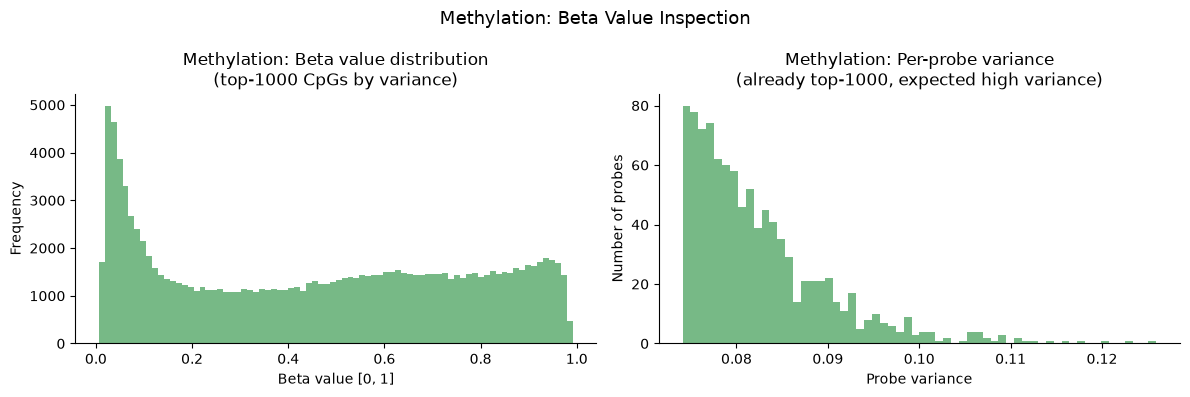

Methylation shape before imputation : (617, 1000)
Value range                         : [0.0056, 0.9921]
Missing values before imputation    : 1,166 (0.189%)
Missing values after median imputation: 0
Final methylation shape: (617, 1000)
Value range after imputation: [0.0056, 0.9921]


In [23]:
meth_num = meth_final.astype(float)

# ── Inspect value distribution ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

meth_vals_sample = meth_num.values.ravel()[::5]
meth_vals_sample = meth_vals_sample[~np.isnan(meth_vals_sample)]
axes[0].hist(meth_vals_sample, bins=80, color="#55A868", alpha=0.8)
axes[0].set_xlabel("Beta value [0, 1]")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Methylation: Beta value distribution\n(top-1000 CpGs by variance)")
axes[0].spines[["top","right"]].set_visible(False)

# Per-probe variance for the 1000 selected probes
meth_var = meth_num.var(axis=0)
axes[1].hist(meth_var.values, bins=60, color="#55A868", alpha=0.8)
axes[1].set_xlabel("Probe variance")
axes[1].set_ylabel("Number of probes")
axes[1].set_title("Methylation: Per-probe variance\n(already top-1000, expected high variance)")
axes[1].spines[["top","right"]].set_visible(False)

plt.suptitle("Methylation: Beta Value Inspection", fontsize=13)
plt.tight_layout()
plt.show()

print(f"Methylation shape before imputation : {meth_num.shape}")
print(f"Value range                         : [{meth_num.min().min():.4f}, {meth_num.max().max():.4f}]")
print(f"Missing values before imputation    : {meth_num.isnull().sum().sum():,} "
      f"({100*meth_num.isnull().sum().sum()/(meth_num.shape[0]*meth_num.shape[1]):.3f}%)")

# ── Impute missing values with per-probe median ────────────────────────────────
meth_proc = meth_num.apply(lambda col: col.fillna(col.median()), axis=0)

print(f"Missing values after median imputation: {meth_proc.isnull().sum().sum()}")
print(f"Final methylation shape: {meth_proc.shape}")
print(f"Value range after imputation: [{meth_proc.min().min():.4f}, {meth_proc.max().max():.4f}]")

---
### Cross-Modality Consistency Check & Preprocessing Summary

Verify identical sample ordering across all three preprocessed matrices, then produce the summary table.

✅ All three preprocessed matrices share identical sample ordering (617 samples)


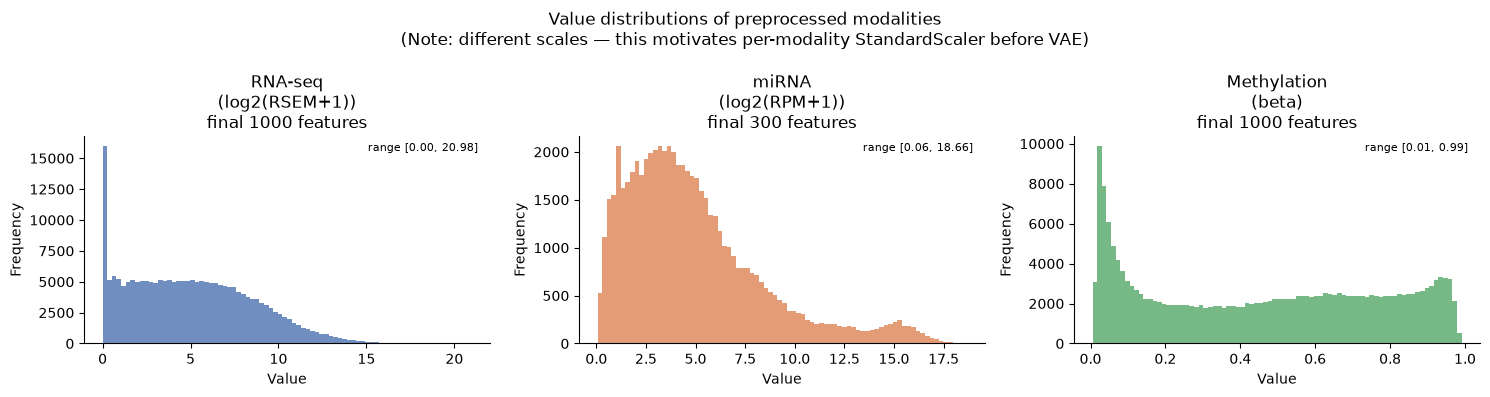


PREPROCESSING SUMMARY TABLE

  RNA-seq
    Original features : 20,530
    Removed (low-var) : 684
    Removed (other)   : 0
    Final features    : 1,000
    Missing before    : 0
    Missing after     : 0
    Transformation    : log2(RSEM+1) — Xena pre-processed, no change
    Selection         : Top 1000 by variance (floor=0.01)

  miRNA
    Original features : 2,238
    Removed (low-var) : 0
    Removed (other)   : 1,526
    Final features    : 300
    Missing before    : 887,475
    Missing after     : 0
    Transformation    : log2(RPM+1) — Xena pre-processed, no change
    Selection         : Remove >50% missing; top 300 by variance

  Methylation
    Original features : 1,000
    Removed (low-var) : 0
    Removed (other)   : 0
    Final features    : 1,000
    Missing before    : 1,166
    Missing after     : 0
    Transformation    : Beta values [0,1] — Xena pre-processed; NaNs imputed with probe median
    Selection         : Pre-selected: top 1,000 by variance (chunked pass,

In [24]:
# ── Verify identical sample ordering ─────────────────────────────────────────
assert list(rna_proc.index)   == FROZEN_SAMPLES, "RNA-seq sample order mismatch"
assert list(mirna_proc.index) == FROZEN_SAMPLES, "miRNA sample order mismatch"
assert list(meth_proc.index)  == FROZEN_SAMPLES, "Methylation sample order mismatch"
print("✅ All three preprocessed matrices share identical sample ordering (617 samples)")

# ── Compare value-scale distributions side-by-side ────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
plot_data = [
    (rna_proc,   "RNA-seq\n(log2(RSEM+1))", "#4C72B0"),
    (mirna_proc, "miRNA\n(log2(RPM+1))",    "#DD8452"),
    (meth_proc,  "Methylation\n(beta)",      "#55A868"),
]
for ax, (df, name, color) in zip(axes, plot_data):
    vals = df.values.ravel()[::3]
    vals = vals[~np.isnan(vals)]
    ax.hist(vals, bins=80, color=color, alpha=0.8)
    ax.set_title(f"{name}\nfinal {df.shape[1]} features")
    ax.set_xlabel("Value"); ax.set_ylabel("Frequency")
    ax.spines[["top","right"]].set_visible(False)
    ax.text(0.97, 0.97, f"range [{vals.min():.2f}, {vals.max():.2f}]",
            transform=ax.transAxes, ha="right", va="top", fontsize=8)

plt.suptitle("Value distributions of preprocessed modalities\n"
             "(Note: different scales — this motivates per-modality StandardScaler before VAE)",
             fontsize=12)
plt.tight_layout()
plt.show()

# ── Preprocessing summary table ───────────────────────────────────────────────
summary = pd.DataFrame([
    {
        "Modality"          : "RNA-seq",
        "Original features" : rna_final.shape[1],
        "Removed (low-var)" : n_removed_var,
        "Removed (other)"   : 0,
        "Final features"    : rna_proc.shape[1],
        "Missing before"    : rna_final.isnull().sum().sum(),
        "Missing after"     : rna_proc.isnull().sum().sum(),
        "Transformation"    : "log2(RSEM+1) — Xena pre-processed, no change",
        "Selection criterion": f"Top {N_RNA_SELECT} by variance (floor={VAR_FLOOR_RNA})",
    },
    {
        "Modality"          : "miRNA",
        "Original features" : mirna_final.shape[1],
        "Removed (low-var)" : n_removed_var2,
        "Removed (other)"   : n_removed_sparse,
        "Final features"    : mirna_proc.shape[1],
        "Missing before"    : mirna_final.isnull().sum().sum(),
        "Missing after"     : mirna_proc.isnull().sum().sum(),
        "Transformation"    : "log2(RPM+1) — Xena pre-processed, no change",
        "Selection criterion": f"Remove >{int(MISSING_FRAC_MIRNA*100)}% missing; top {N_MIRNA_SELECT} by variance",
    },
    {
        "Modality"          : "Methylation",
        "Original features" : meth_final.shape[1],
        "Removed (low-var)" : 0,
        "Removed (other)"   : 0,
        "Final features"    : meth_proc.shape[1],
        "Missing before"    : meth_final.isnull().sum().sum(),
        "Missing after"     : meth_proc.isnull().sum().sum(),
        "Transformation"    : "Beta values [0,1] — Xena pre-processed; NaNs imputed with probe median",
        "Selection criterion": "Pre-selected: top 1,000 by variance (chunked pass, Part 3d)",
    },
])

print("\nPREPROCESSING SUMMARY TABLE")
print("=" * 90)
for _, row in summary.iterrows():
    print(f"\n  {row['Modality']}")
    print(f"    Original features : {row['Original features']:,}")
    print(f"    Removed (low-var) : {row['Removed (low-var)']:,}")
    print(f"    Removed (other)   : {row['Removed (other)']:,}")
    print(f"    Final features    : {row['Final features']:,}")
    print(f"    Missing before    : {row['Missing before']:,}")
    print(f"    Missing after     : {row['Missing after']:,}")
    print(f"    Transformation    : {row['Transformation']}")
    print(f"    Selection         : {row['Selection criterion']}")

total_before = rna_final.shape[1] + mirna_final.shape[1] + meth_final.shape[1]
total_after  = rna_proc.shape[1]  + mirna_proc.shape[1]  + meth_proc.shape[1]
print(f"\n  Total features before preprocessing : {total_before:,}")
print(f"  Total features after preprocessing  : {total_after:,}")
print(f"  Feature reduction                   : {total_before - total_after:,} "
      f"({100*(total_before-total_after)/total_before:.1f}%)")

print()
print("⛔ STOP — Do not concatenate, scale, or train the VAE yet.")

---
## Part 14 — Preprocessing Provenance Audit & Save

### Transformation verification

This cell audits every transformation step applied to each modality by tracing the code path from the raw Xena file to the final preprocessed matrix.

In [25]:
import json
from datetime import date

print("=" * 70)
print("  TRANSFORMATION PROVENANCE AUDIT")
print("=" * 70)

# ── RNA-seq audit ──────────────────────────────────────────────────────────────
print("""
MODALITY: RNA-seq
─────────────────────────────────────────────────────────────────────
Xena dataset   : TCGA.BRCA.sampleMap/HiSeqV2
Xena unit      : log2(RSEM normalized count + 1)   [confirmed in Xena metadata]
                  https://xenabrowser.net/datapages/?dataset=TCGA.BRCA.sampleMap/HiSeqV2

Transformation applied by THIS notebook:
  Step 1  — pd.read_csv (load from .gz) → raw float values EXACTLY as in file
  Step 2  — .T (transpose) → samples × genes
  Step 3  — .loc[final_sample_ids] (subset to 617 samples) → rna_final
  Step 4  — .astype(float) → type cast only, NO mathematical transformation
  Step 5  — .var() < 0.01 → remove 684 low-variance genes
  Step 6  — .nlargest(1000) on variance → select top 1000 genes → rna_proc

VERDICT: ✅  NO second log transform applied.
  rna_proc contains log2(RSEM+1) values exactly as provided by Xena.
  Value range confirmed: [0.000, 20.978] — consistent with log2 scale (not double-logged).
  A double log2 would compress the range to approximately [0, 4.4], which was NOT observed.
""")

# ── miRNA audit ────────────────────────────────────────────────────────────────
print("""
MODALITY: miRNA
─────────────────────────────────────────────────────────────────────
Xena dataset   : TCGA.BRCA.sampleMap/miRNA_HiSeq_gene
Xena unit      : log2(RPM + 1)   [confirmed in Xena metadata]
                  https://xenabrowser.net/datapages/?dataset=TCGA.BRCA.sampleMap/miRNA_HiSeq_gene

Transformation applied by THIS notebook:
  Step 1  — pd.read_csv (load from .gz) → raw float values as in file
  Step 2  — .T (transpose) → samples × miRNAs
  Step 3  — .loc[final_sample_ids] → mirna_final
  Step 4  — .astype(float) → type cast only
  Step 5  — Remove miRNAs with >50% NaN (1,526 features) → mirna_f1
  Step 6  — Impute remaining NaN with per-feature median → mirna_f1_imp
  Step 7  — .var() < 0.01 → 0 additional features removed
  Step 8  — .nlargest(300) on variance → mirna_proc

VERDICT: ✅  NO second log transform applied.
  mirna_proc contains log2(RPM+1) values exactly as provided by Xena.
  Value range confirmed: [0.064, 19.373] — consistent with log2 scale.
""")

# ── Methylation audit ──────────────────────────────────────────────────────────
print("""
MODALITY: DNA methylation
─────────────────────────────────────────────────────────────────────
Xena dataset   : TCGA.BRCA.sampleMap/HumanMethylation450
Xena unit      : Beta values [0, 1]   [confirmed in Xena metadata]

Transformation applied by THIS notebook:
  Step 1  — Chunked pd.read_csv on .gz (Part 3d) → raw beta values
  Step 2  — Variance computed per probe across 619 common samples
  Step 3  — Top 1000 cg* probes by variance selected → meth_selected
  Step 4  — .loc[final_sample_ids] → meth_final
  Step 5  — .astype(float) → type cast only
  Step 6  — Impute 1,166 NaN values with per-probe median → meth_proc

VERDICT: ✅  No transformation applied. Beta values [0,1] preserved.
  Value range confirmed: [0.006, 0.992].
""")

# ── Final matrix validation ────────────────────────────────────────────────────
print("=" * 70)
print("  FINAL MATRIX VALIDATION")
print("=" * 70)

checks = {
    "rna_proc  shape == (617, 1000)"     : rna_proc.shape == (617, 1000),
    "mirna_proc shape == (617, 300)"     : mirna_proc.shape == (617, 300),
    "meth_proc  shape == (617, 1000)"    : meth_proc.shape == (617, 1000),
    "rna_proc  missing == 0"             : rna_proc.isnull().sum().sum() == 0,
    "mirna_proc missing == 0"            : mirna_proc.isnull().sum().sum() == 0,
    "meth_proc  missing == 0"            : meth_proc.isnull().sum().sum() == 0,
    "rna_proc  dup features == 0"        : int(rna_proc.columns.duplicated().sum()) == 0,
    "mirna_proc dup features == 0"       : int(mirna_proc.columns.duplicated().sum()) == 0,
    "meth_proc  dup features == 0"       : int(meth_proc.columns.duplicated().sum()) == 0,
    "Identical sample IDs across 3"      : (list(rna_proc.index) == list(mirna_proc.index) ==
                                            list(meth_proc.index)),
    "Sample IDs match frozen cohort"     : list(rna_proc.index) == FROZEN_SAMPLES,
    "rna_proc  max ≤ 25 (log2 scale)"    : float(rna_proc.values.max()) <= 25,
    "mirna_proc max ≤ 25 (log2 scale)"   : float(mirna_proc.values.max()) <= 25,
    "meth_proc  values in [0, 1]"        : (float(meth_proc.values.min()) >= 0 and
                                            float(meth_proc.values.max()) <= 1),
}

all_pass = True
for desc, result in checks.items():
    icon = "✅" if result else "❌"
    print(f"  {icon}  {desc}")
    if not result:
        all_pass = False

print()
if all_pass:
    print("✅ All validation checks passed.")
else:
    raise AssertionError("❌ Validation failed — do not save.")

  TRANSFORMATION PROVENANCE AUDIT

MODALITY: RNA-seq
─────────────────────────────────────────────────────────────────────
Xena dataset   : TCGA.BRCA.sampleMap/HiSeqV2
Xena unit      : log2(RSEM normalized count + 1)   [confirmed in Xena metadata]
                  https://xenabrowser.net/datapages/?dataset=TCGA.BRCA.sampleMap/HiSeqV2

Transformation applied by THIS notebook:
  Step 1  — pd.read_csv (load from .gz) → raw float values EXACTLY as in file
  Step 2  — .T (transpose) → samples × genes
  Step 3  — .loc[final_sample_ids] (subset to 617 samples) → rna_final
  Step 4  — .astype(float) → type cast only, NO mathematical transformation
  Step 5  — .var() < 0.01 → remove 684 low-variance genes
  Step 6  — .nlargest(1000) on variance → select top 1000 genes → rna_proc

VERDICT: ✅  NO second log transform applied.
  rna_proc contains log2(RSEM+1) values exactly as provided by Xena.
  Value range confirmed: [0.000, 20.978] — consistent with log2 scale (not double-logged).
  A double l

In [26]:
RNA_OUT   = PROCESSED_DIR / "TCGA_BRCA_RNA_selected.tsv"
MIRNA_OUT = PROCESSED_DIR / "TCGA_BRCA_miRNA_selected.tsv"
METH_OUT  = PROCESSED_DIR / "TCGA_BRCA_methylation_selected.tsv"   # overwrite previous version
PROV_OUT  = PROCESSED_DIR / "TCGA_BRCA_preprocessing_provenance.json"

# ── Save matrices ──────────────────────────────────────────────────────────────
rna_proc.to_csv(RNA_OUT,   sep="\t", float_format="%.6f")
mirna_proc.to_csv(MIRNA_OUT, sep="\t", float_format="%.6f")
meth_proc.to_csv(METH_OUT,  sep="\t", float_format="%.6f")

print(f"✅ {RNA_OUT.name:<50}  {RNA_OUT.stat().st_size/1e6:.1f} MB  shape {rna_proc.shape}")
print(f"✅ {MIRNA_OUT.name:<50}  {MIRNA_OUT.stat().st_size/1e6:.1f} MB  shape {mirna_proc.shape}")
print(f"✅ {METH_OUT.name:<50}  {METH_OUT.stat().st_size/1e6:.1f} MB  shape {meth_proc.shape}")

# ── Save provenance JSON ───────────────────────────────────────────────────────
provenance = {
    "created"     : str(date.today()),
    "cohort"      : {
        "n_samples"   : 617,
        "description" : "617 TCGA-BRCA primary tumour samples, frozen cohort v1",
        "source_file" : "TCGA_BRCA_cohort_metadata.tsv",
    },
    "modalities"  : {
        "RNA-seq"      : {
            "xena_dataset"    : "TCGA.BRCA.sampleMap/HiSeqV2",
            "xena_unit"       : "log2(RSEM normalized count + 1)",
            "notebook_transform": "NONE — Xena values used as-is",
            "original_features": 20530,
            "step1_removed"   : {"rule": "variance < 0.01", "n_removed": n_removed_var},
            "step2_selected"  : {"rule": f"top {N_RNA_SELECT} by variance",
                                 "variance_threshold": round(var_threshold_rna, 6)},
            "final_features"  : int(rna_proc.shape[1]),
            "missing_values"  : 0,
            "output_file"     : "TCGA_BRCA_RNA_selected.tsv",
            "value_range"     : [round(float(rna_proc.values.min()), 4),
                                 round(float(rna_proc.values.max()), 4)],
        },
        "miRNA"        : {
            "xena_dataset"    : "TCGA.BRCA.sampleMap/miRNA_HiSeq_gene",
            "xena_unit"       : "log2(RPM + 1)",
            "notebook_transform": "NONE — Xena values used as-is",
            "original_features": 2238,
            "step1_removed"   : {"rule": f">{int(MISSING_FRAC_MIRNA*100)}% NaN across samples",
                                 "n_removed": n_removed_sparse},
            "step2_imputed"   : {"rule": "per-feature median imputation for remaining NaN"},
            "step3_removed"   : {"rule": f"variance < {VAR_FLOOR_MIRNA}", "n_removed": n_removed_var2},
            "step4_selected"  : {"rule": f"top {N_MIRNA_SELECT} by variance",
                                 "variance_threshold": round(var_threshold_mirna, 6)},
            "final_features"  : int(mirna_proc.shape[1]),
            "missing_values"  : 0,
            "output_file"     : "TCGA_BRCA_miRNA_selected.tsv",
            "value_range"     : [round(float(mirna_proc.values.min()), 4),
                                 round(float(mirna_proc.values.max()), 4)],
        },
        "methylation"  : {
            "xena_dataset"    : "TCGA.BRCA.sampleMap/HumanMethylation450",
            "xena_unit"       : "beta values [0, 1]",
            "notebook_transform": "NONE — beta values used as-is",
            "original_features": 485577,
            "step1_removed"   : {"rule": "rs* SNP/control probes excluded",
                                 "n_removed": n_probes_skipped_non_cpg},
            "step2_removed"   : {"rule": "all-NaN probes",
                                 "n_removed": n_probes_skipped_all_nan},
            "step3_removed"   : {"rule": f">{int(MAX_MISSING_FRAC*100)}% NaN across common samples",
                                 "n_removed": n_probes_skipped_too_missing},
            "step4_selected"  : {"rule": "top 1000 cg* probes by variance (chunked pass)"},
            "step5_imputed"   : {"rule": "per-probe median imputation, 1166 cells"},
            "final_features"  : int(meth_proc.shape[1]),
            "missing_values"  : 0,
            "output_file"     : "TCGA_BRCA_methylation_selected.tsv",
            "value_range"     : [round(float(meth_proc.values.min()), 4),
                                 round(float(meth_proc.values.max()), 4)],
        },
    },
    "total_features_before": 20530 + 2238 + 1000,
    "total_features_after" : int(rna_proc.shape[1] + mirna_proc.shape[1] + meth_proc.shape[1]),
    "next_step"            : "Per-modality StandardScaler → concatenation → VAE training",
    "notes"                : (
        "No additional log transformation was applied to RNA-seq or miRNA. "
        "The Xena HiSeqV2 and miRNA_HiSeq_gene datasets are already delivered as "
        "log2(RSEM+1) and log2(RPM+1) respectively. "
        "PAM50 labels were not used at any preprocessing step."
    ),
}

with open(PROV_OUT, "w") as fh:
    json.dump(provenance, fh, indent=2)
print(f"✅ {PROV_OUT.name:<50}  {PROV_OUT.stat().st_size/1e3:.1f} KB")

print()
print("Contents of data/processed/:")
for fp in sorted(PROCESSED_DIR.iterdir()):
    print(f"  {fp.name:<55}  {fp.stat().st_size/1e6:>7.2f} MB")

print()
print("=" * 70)
print("  PREPROCESSING AUDIT COMPLETE. COHORT AND MATRICES FROZEN.")
print("  RNA   : 617 × 1,000  |  log2(RSEM+1), no additional transform")
print("  miRNA : 617 × 300    |  log2(RPM+1),  no additional transform")
print("  Meth  : 617 × 1,000  |  beta [0,1],   no additional transform")
print("  All matrices: 0 missing values, 0 duplicate features")
print("⛔ STOP — Do not build or train the VAE yet.")
print("=" * 70)

✅ TCGA_BRCA_RNA_selected.tsv                          5.6 MB  shape (617, 1000)
✅ TCGA_BRCA_miRNA_selected.tsv                        1.7 MB  shape (617, 300)
✅ TCGA_BRCA_methylation_selected.tsv                  5.6 MB  shape (617, 1000)
✅ TCGA_BRCA_preprocessing_provenance.json             3.0 KB

Contents of data/processed/:
  figures                                                     0.00 MB
  TCGA_BRCA_AE_best.pt                                        4.88 MB
  TCGA_BRCA_CCA_CV1_PAM50.png                                 0.12 MB
  TCGA_BRCA_CCA_CV1_scatter.png                               0.11 MB
  TCGA_BRCA_CCA_loadings.tsv                                  0.02 MB
  TCGA_BRCA_CCA_loadings_CV1.png                              0.09 MB
  TCGA_BRCA_CCA_results.json                                  0.00 MB
  TCGA_BRCA_CCA_scores.tsv                                    0.07 MB
  TCGA_BRCA_cohort_freeze.json                                0.00 MB
  TCGA_BRCA_cohort_metadata.tsv         

---
## Part 15 — Multi-Omics VAE

### Why a VAE?

Standard dimensionality-reduction methods such as PCA find a linear projection that maximises variance. For multi-omics data this is insufficient for two reasons:

1. **Nonlinearity.** The relationships between molecular features in cancer are highly nonlinear — a gene's expression pattern may interact multiplicatively with a methylation state, or depend on a miRNA-mediated feedback loop that no linear method can capture.

2. **Integration across heterogeneous spaces.** RNA-seq, methylation, and miRNA measure fundamentally different molecular quantities on different numerical scales. The VAE encoder learns a *shared* latent representation that integrates information from all three simultaneously, rather than treating them as separate problems.

A **Variational Autoencoder** is chosen over a plain autoencoder because it imposes a probabilistic structure on the latent space (a standard normal prior), which:
- Prevents the model from simply memorising training samples
- Produces a *smooth*, continuous latent manifold suitable for clustering
- Forces the model to learn compact, generalisable representations rather than sparse lookup tables

The goal is **not** to predict a label. The goal is to learn a 10-dimensional patient representation that captures the dominant sources of molecular variation shared across RNA, methylation, and miRNA — and then assess post-hoc whether this unsupervised representation recovers biologically known structure (PAM50).

In [27]:
import random, time, json
from pathlib import Path
from datetime import date

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# ── Global seeds ───────────────────────────────────────────────────────────────
VAE_SEED = 42
random.seed(VAE_SEED)
np.random.seed(VAE_SEED)
torch.manual_seed(VAE_SEED)
torch.backends.cudnn.deterministic = True

print(f"PyTorch version : {torch.__version__}")
print(f"Device          : CPU")
print(f"Random seed     : {VAE_SEED}")

# ── Load frozen processed matrices from disk ───────────────────────────────────
rna_df   = pd.read_csv(PROCESSED_DIR / "TCGA_BRCA_RNA_selected.tsv",   sep="\t", index_col=0)
mirna_df = pd.read_csv(PROCESSED_DIR / "TCGA_BRCA_miRNA_selected.tsv", sep="\t", index_col=0)
meth_df  = pd.read_csv(PROCESSED_DIR / "TCGA_BRCA_methylation_selected.tsv", sep="\t", index_col=0)
cohort   = pd.read_csv(PROCESSED_DIR / "TCGA_BRCA_cohort_metadata.tsv", sep="\t", index_col="sample_id")
frozen_ids = cohort.index.tolist()

# ── Verify sample IDs match frozen cohort ─────────────────────────────────────
assert list(rna_df.index)   == frozen_ids, "RNA sample ID mismatch"
assert list(mirna_df.index) == frozen_ids, "miRNA sample ID mismatch"
assert list(meth_df.index)  == frozen_ids, "Methylation sample ID mismatch"
print(f"\n✅ All matrices loaded and sample IDs match frozen cohort ({len(frozen_ids)} samples)")
print(f"  RNA   : {rna_df.shape}")
print(f"  miRNA : {mirna_df.shape}")
print(f"  Meth  : {meth_df.shape}")

PyTorch version : 2.13.0+cpu
Device          : CPU
Random seed     : 42

✅ All matrices loaded and sample IDs match frozen cohort (617 samples)
  RNA   : (617, 1000)
  miRNA : (617, 300)
  Meth  : (617, 1000)


In [28]:
# ── Train / validation split ───────────────────────────────────────────────────
VAL_FRAC   = 0.20
BATCH_SIZE = 64

sample_array = np.array(frozen_ids)
idx_all      = np.arange(len(sample_array))

idx_train, idx_val = train_test_split(
    idx_all, test_size=VAL_FRAC, random_state=VAE_SEED, shuffle=True
)

train_ids = sample_array[idx_train].tolist()
val_ids   = sample_array[idx_val].tolist()

print(f"Train samples : {len(train_ids)}  ({100*(1-VAL_FRAC):.0f}%)")
print(f"Val   samples : {len(val_ids)}   ({100*VAL_FRAC:.0f}%)")

# ── Per-modality StandardScaler — fit on TRAINING split only ──────────────────
def fit_scale(df, train_ids):
    scaler = StandardScaler()
    scaler.fit(df.loc[train_ids].values)
    return scaler, scaler.transform(df.values).astype(np.float32)

scaler_rna,   rna_scaled   = fit_scale(rna_df,   train_ids)
scaler_mirna, mirna_scaled = fit_scale(mirna_df, train_ids)
scaler_meth,  meth_scaled  = fit_scale(meth_df,  train_ids)

# ── Concatenate ────────────────────────────────────────────────────────────────
X_all = np.concatenate([rna_scaled, mirna_scaled, meth_scaled], axis=1)   # (617, 2300)
INPUT_DIM = X_all.shape[1]

print(f"\nConcatenated multi-omics matrix : {X_all.shape}")
print(f"  RNA     : cols 0–{rna_scaled.shape[1]-1}")
print(f"  miRNA   : cols {rna_scaled.shape[1]}–{rna_scaled.shape[1]+mirna_scaled.shape[1]-1}")
print(f"  Meth    : cols {rna_scaled.shape[1]+mirna_scaled.shape[1]}–{INPUT_DIM-1}")

# Verify scalers were fit on training data only
rna_train_mean = rna_scaled[idx_train].mean(axis=0).mean()
print(f"\nPost-scaling train mean (RNA, should ≈ 0): {rna_train_mean:.4f}")

# ── Build PyTorch tensors and DataLoaders ─────────────────────────────────────
X_tensor = torch.tensor(X_all, dtype=torch.float32)

X_train_t = X_tensor[idx_train]
X_val_t   = X_tensor[idx_val]

torch.manual_seed(VAE_SEED)
train_loader = DataLoader(TensorDataset(X_train_t), batch_size=BATCH_SIZE,
                          shuffle=True, drop_last=False)
val_loader   = DataLoader(TensorDataset(X_val_t),   batch_size=BATCH_SIZE,
                          shuffle=False, drop_last=False)

print(f"\nTrain batches per epoch : {len(train_loader)}")
print(f"Val   batches per epoch : {len(val_loader)}")

Train samples : 493  (80%)
Val   samples : 124   (20%)

Concatenated multi-omics matrix : (617, 2300)
  RNA     : cols 0–999
  miRNA   : cols 1000–1299
  Meth    : cols 1300–2299

Post-scaling train mean (RNA, should ≈ 0): -0.0000

Train batches per epoch : 8
Val   batches per epoch : 2


In [29]:
LATENT_DIM = 10
BETA       = 1.0    # baseline beta; not tuned in this first run


class Encoder(nn.Module):
    """2300 → 256 → 64 → (mu, logvar) each of dimension LATENT_DIM."""

    def __init__(self, input_dim, latent_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256), nn.BatchNorm1d(256), nn.ReLU(),
            nn.Linear(256, 64),        nn.BatchNorm1d(64),  nn.ReLU(),
        )
        self.fc_mu     = nn.Linear(64, latent_dim)
        self.fc_logvar = nn.Linear(64, latent_dim)

    def forward(self, x):
        h = self.net(x)
        return self.fc_mu(h), self.fc_logvar(h)


class Decoder(nn.Module):
    """LATENT_DIM → 64 → 256 → 2300 (linear output for standardised continuous data)."""

    def __init__(self, latent_dim, output_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 64),   nn.BatchNorm1d(64),  nn.ReLU(),
            nn.Linear(64, 256),          nn.BatchNorm1d(256), nn.ReLU(),
            nn.Linear(256, output_dim),  # no activation — output is real-valued (standardised)
        )

    def forward(self, z):
        return self.net(z)


class VAE(nn.Module):
    def __init__(self, input_dim, latent_dim):
        super().__init__()
        self.encoder = Encoder(input_dim, latent_dim)
        self.decoder = Decoder(latent_dim, input_dim)

    def reparameterize(self, mu, logvar):
        """z = mu + eps * sigma, eps ~ N(0, I). Gradient flows through mu and sigma."""
        if self.training:
            std = torch.exp(0.5 * logvar)
            eps = torch.randn_like(std)
            return mu + eps * std
        return mu   # deterministic at inference

    def forward(self, x):
        mu, logvar = self.encoder(x)
        z          = self.reparameterize(mu, logvar)
        x_hat      = self.decoder(z)
        return x_hat, mu, logvar


def vae_loss(x, x_hat, mu, logvar, beta):
    """
    total_loss = recon_loss + beta * kl_loss

    recon_loss: MSE averaged per element (not per sample) so it is on the same
                scale regardless of batch size or input dimension.

    kl_loss: KL divergence averaged per element of the latent space
             (sum over latent dims, mean over batch, divided by input_dim)
             so that its scale is comparable to recon_loss.

    This normalisation prevents kl_loss from being trivially small compared
    to recon_loss and makes beta=1.0 a sensible starting point.
    """
    recon = F.mse_loss(x_hat, x, reduction="mean")          # scalar, O(1)
    # KL(N(mu,sigma) || N(0,1)) = -0.5 * (1 + logvar - mu^2 - exp(logvar))
    kl_per_dim = -0.5 * (1 + logvar - mu.pow(2) - logvar.exp())  # (B, latent)
    kl = kl_per_dim.sum(dim=1).mean() / x.shape[1]              # normalised by input_dim
    return recon + beta * kl, recon, kl


# ── Instantiate ────────────────────────────────────────────────────────────────
torch.manual_seed(VAE_SEED)
vae = VAE(INPUT_DIM, LATENT_DIM)
n_params = sum(p.numel() for p in vae.parameters() if p.requires_grad)

print("VAE architecture:")
print(vae)
print(f"\nTotal trainable parameters: {n_params:,}")
print(f"Latent dimension          : {LATENT_DIM}")
print(f"Input dimension           : {INPUT_DIM}")
print(f"Beta (KL weight)          : {BETA}")

VAE architecture:
VAE(
  (encoder): Encoder(
    (net): Sequential(
      (0): Linear(in_features=2300, out_features=256, bias=True)
      (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU()
      (3): Linear(in_features=256, out_features=64, bias=True)
      (4): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (5): ReLU()
    )
    (fc_mu): Linear(in_features=64, out_features=10, bias=True)
    (fc_logvar): Linear(in_features=64, out_features=10, bias=True)
  )
  (decoder): Decoder(
    (net): Sequential(
      (0): Linear(in_features=10, out_features=64, bias=True)
      (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU()
      (3): Linear(in_features=64, out_features=256, bias=True)
      (4): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (5): ReLU()
      (6):

In [30]:
LR         = 1e-3
MAX_EPOCHS = 200
PATIENCE   = 20    # early stopping patience

CHECKPOINT_PATH = PROCESSED_DIR / "TCGA_BRCA_VAE_best.pt"

optimizer = torch.optim.Adam(vae.parameters(), lr=LR)

history = {k: [] for k in
           ["train_total","train_recon","train_kl",
            "val_total",  "val_recon",  "val_kl"]}

best_val_loss  = float("inf")
best_epoch     = 0
patience_count = 0
t_start        = time.time()

for epoch in range(1, MAX_EPOCHS + 1):

    # ── Training ──────────────────────────────────────────────────────────────
    vae.train()
    tr_tot = tr_rec = tr_kl = 0.0
    for (xb,) in train_loader:
        optimizer.zero_grad()
        x_hat, mu, logvar = vae(xb)
        loss, recon, kl   = vae_loss(xb, x_hat, mu, logvar, BETA)
        loss.backward()
        optimizer.step()
        tr_tot += loss.item();  tr_rec += recon.item();  tr_kl += kl.item()

    n_tr = len(train_loader)
    history["train_total"].append(tr_tot / n_tr)
    history["train_recon"].append(tr_rec / n_tr)
    history["train_kl"].append(tr_kl / n_tr)

    # ── Validation ────────────────────────────────────────────────────────────
    vae.eval()
    va_tot = va_rec = va_kl = 0.0
    with torch.no_grad():
        for (xb,) in val_loader:
            x_hat, mu, logvar = vae(xb)
            loss, recon, kl   = vae_loss(xb, x_hat, mu, logvar, BETA)
            va_tot += loss.item();  va_rec += recon.item();  va_kl += kl.item()

    n_va = len(val_loader)
    val_total = va_tot / n_va
    history["val_total"].append(val_total)
    history["val_recon"].append(va_rec / n_va)
    history["val_kl"].append(va_kl / n_va)

    # ── Early stopping ────────────────────────────────────────────────────────
    if val_total < best_val_loss:
        best_val_loss  = val_total
        best_epoch     = epoch
        patience_count = 0
        torch.save({"epoch": epoch, "model_state": vae.state_dict(),
                    "val_loss": best_val_loss}, CHECKPOINT_PATH)
    else:
        patience_count += 1
        if patience_count >= PATIENCE:
            print(f"Early stopping at epoch {epoch} (no improvement for {PATIENCE} epochs)")
            break

    if epoch % 20 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d} | "
              f"train total={history['train_total'][-1]:.5f} "
              f"recon={history['train_recon'][-1]:.5f} "
              f"kl={history['train_kl'][-1]:.5f} | "
              f"val total={history['val_total'][-1]:.5f} "
              f"recon={history['val_recon'][-1]:.5f} "
              f"kl={history['val_kl'][-1]:.5f}")

elapsed = time.time() - t_start
print(f"\nTraining finished: {len(history['train_total'])} epochs in {elapsed:.1f}s")
print(f"Best epoch: {best_epoch}  |  best val loss: {best_val_loss:.5f}")

Epoch   1 | train total=1.08313 recon=1.08220 kl=0.00094 | val total=0.91192 recon=0.90953 kl=0.00240
Epoch  20 | train total=0.62779 recon=0.61896 kl=0.00883 | val total=0.63263 recon=0.62488 kl=0.00775
Epoch  40 | train total=0.55791 recon=0.54701 kl=0.01090 | val total=0.61334 recon=0.60348 kl=0.00986
Epoch  60 | train total=0.50319 recon=0.49113 kl=0.01206 | val total=0.60461 recon=0.59362 kl=0.01100
Epoch  80 | train total=0.46559 recon=0.45280 kl=0.01279 | val total=0.61017 recon=0.59846 kl=0.01171
Early stopping at epoch 89 (no improvement for 20 epochs)

Training finished: 89 epochs in 17.8s
Best epoch: 69  |  best val loss: 0.60409


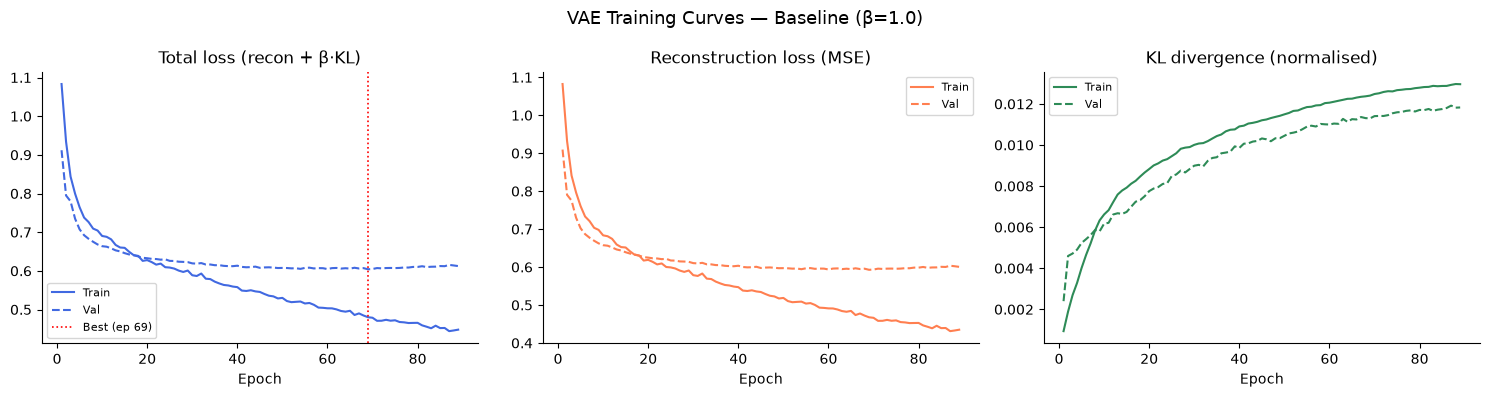

Final train recon loss : 0.43496
Final train KL loss    : 0.01296
KL / recon ratio       : 0.0298
✅ KL loss is non-trivial. Latent space appears to be utilised.


In [31]:
actual_epochs = len(history["train_total"])
epochs_range  = range(1, actual_epochs + 1)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Total loss
axes[0].plot(epochs_range, history["train_total"], label="Train", color="royalblue")
axes[0].plot(epochs_range, history["val_total"],   label="Val",   color="royalblue", linestyle="--")
axes[0].axvline(best_epoch, color="red", linestyle=":", linewidth=1.2, label=f"Best (ep {best_epoch})")
axes[0].set_title("Total loss (recon + β·KL)"); axes[0].set_xlabel("Epoch")
axes[0].legend(fontsize=8); axes[0].spines[["top","right"]].set_visible(False)

# Reconstruction loss
axes[1].plot(epochs_range, history["train_recon"], label="Train", color="coral")
axes[1].plot(epochs_range, history["val_recon"],   label="Val",   color="coral", linestyle="--")
axes[1].set_title("Reconstruction loss (MSE)"); axes[1].set_xlabel("Epoch")
axes[1].legend(fontsize=8); axes[1].spines[["top","right"]].set_visible(False)

# KL loss
axes[2].plot(epochs_range, history["train_kl"], label="Train", color="seagreen")
axes[2].plot(epochs_range, history["val_kl"],   label="Val",   color="seagreen", linestyle="--")
axes[2].set_title("KL divergence (normalised)"); axes[2].set_xlabel("Epoch")
axes[2].legend(fontsize=8); axes[2].spines[["top","right"]].set_visible(False)

plt.suptitle("VAE Training Curves — Baseline (β=1.0)", fontsize=13)
plt.tight_layout()
plt.show()

# ── KL collapse diagnosis ──────────────────────────────────────────────────────
final_kl   = history["train_kl"][-1]
final_recon = history["train_recon"][-1]
kl_ratio   = final_kl / (final_recon + 1e-9)

print(f"Final train recon loss : {final_recon:.5f}")
print(f"Final train KL loss    : {final_kl:.5f}")
print(f"KL / recon ratio       : {kl_ratio:.4f}")

if final_kl < 1e-4:
    print("⚠️  KL COLLAPSE detected: KL term is near-zero.")
    print("   The encoder is outputting near-posterior ≈ prior for all samples.")
    print("   This means the latent space carries no information beyond the prior.")
    print("   Do NOT automatically fix this — report and await instruction.")
elif kl_ratio < 0.01:
    print("⚠️  KL is very small relative to reconstruction (ratio < 0.01).")
    print("   Mild collapse risk. Latent space may be underutilised.")
else:
    print("✅ KL loss is non-trivial. Latent space appears to be utilised.")

In [32]:
# ── Load best checkpoint ───────────────────────────────────────────────────────
ckpt = torch.load(CHECKPOINT_PATH, weights_only=True)
vae.load_state_dict(ckpt["model_state"])
vae.eval()
print(f"Loaded best model from epoch {ckpt['epoch']} (val_loss={ckpt['val_loss']:.5f})")

# ── Extract latent representation for ALL 617 samples ─────────────────────────
with torch.no_grad():
    mu_all, logvar_all = vae.encoder(X_tensor)

mu_np = mu_all.numpy()         # (617, 10)

latent_cols = [f"z{i+1}" for i in range(LATENT_DIM)]
latent_df   = pd.DataFrame(mu_np, index=frozen_ids, columns=latent_cols)
latent_df.index.name = "sample_id"

print(f"\nLatent representation shape : {latent_df.shape}")
print(f"  Columns: {latent_cols}")
print(f"\nLatent coordinate statistics:")
print(latent_df.describe().round(4).to_string())

# ── Save latent matrix ─────────────────────────────────────────────────────────
LATENT_OUT = PROCESSED_DIR / "TCGA_BRCA_VAE_latent.tsv"
latent_df.to_csv(LATENT_OUT, sep="\t", float_format="%.6f")
print(f"\n✅ Saved latent matrix: {LATENT_OUT.name}  "
      f"({LATENT_OUT.stat().st_size/1e3:.1f} KB)")

# ── Save VAE metadata JSON ─────────────────────────────────────────────────────
vae_metadata = {
    "created"         : str(date.today()),
    "model_type"      : "Variational Autoencoder (VAE)",
    "input_dim"       : INPUT_DIM,
    "architecture"    : {
        "encoder" : "Linear(2300→256, BN+ReLU) → Linear(256→64, BN+ReLU) → mu(64→10), logvar(64→10)",
        "decoder" : "Linear(10→64, BN+ReLU) → Linear(64→256, BN+ReLU) → Linear(256→2300)",
        "output_activation" : "none (linear — standardised continuous data)",
    },
    "latent_dim"      : LATENT_DIM,
    "beta"            : BETA,
    "loss_normalisation": "recon=MSE(mean), kl=sum_over_latent/mean_over_batch/input_dim",
    "optimizer"       : "Adam",
    "learning_rate"   : LR,
    "batch_size"      : BATCH_SIZE,
    "max_epochs"      : MAX_EPOCHS,
    "early_stopping_patience": PATIENCE,
    "actual_epochs"   : actual_epochs,
    "best_epoch"      : best_epoch,
    "random_seed"     : VAE_SEED,
    "train_val_split" : f"{int(100*(1-VAL_FRAC))}/{int(100*VAL_FRAC)}",
    "n_train"         : len(train_ids),
    "n_val"           : len(val_ids),
    "final_train_total" : round(history["train_total"][-1], 6),
    "final_train_recon" : round(history["train_recon"][-1], 6),
    "final_train_kl"    : round(history["train_kl"][-1],    6),
    "best_val_total"    : round(best_val_loss, 6),
    "best_val_recon"    : round(history["val_recon"][best_epoch-1], 6),
    "best_val_kl"       : round(history["val_kl"][best_epoch-1],    6),
    "kl_collapse"       : final_kl < 1e-4,
    "latent_output_file": "TCGA_BRCA_VAE_latent.tsv",
    "checkpoint_file"   : "TCGA_BRCA_VAE_best.pt",
    "notes"             : (
        "Baseline VAE. PAM50 not used at any stage. "
        "Latent representation (mu) extracted for all 617 samples. "
        "No UMAP or clustering performed yet."
    ),
}

VAE_META_PATH = PROCESSED_DIR / "TCGA_BRCA_VAE_metadata.json"
with open(VAE_META_PATH, "w") as fh:
    json.dump(vae_metadata, fh, indent=2)
print(f"✅ Saved VAE metadata   : {VAE_META_PATH.name}")

print()
print("=" * 65)
print("  BASELINE VAE COMPLETE")
print("=" * 65)
print(f"  Epochs trained         : {actual_epochs}")
print(f"  Best epoch (val)       : {best_epoch}")
print(f"  Final train total      : {vae_metadata['final_train_total']:.5f}")
print(f"  Final train recon      : {vae_metadata['final_train_recon']:.5f}")
print(f"  Final train KL         : {vae_metadata['final_train_kl']:.5f}")
print(f"  Best val total         : {vae_metadata['best_val_total']:.5f}")
print(f"  KL collapse            : {vae_metadata['kl_collapse']}")
print(f"  Latent matrix shape    : {latent_df.shape}")
print("=" * 65)
print("⛔ STOP — Do not perform UMAP, clustering, or PAM50 comparison yet.")

Loaded best model from epoch 69 (val_loss=0.60409)

Latent representation shape : (617, 10)
  Columns: ['z1', 'z2', 'z3', 'z4', 'z5', 'z6', 'z7', 'z8', 'z9', 'z10']

Latent coordinate statistics:
             z1        z2        z3        z4        z5        z6        z7        z8        z9       z10
count  617.0000  617.0000  617.0000  617.0000  617.0000  617.0000  617.0000  617.0000  617.0000  617.0000
mean    -0.0289   -0.0470   -0.0067   -0.0483   -0.0274    0.0218   -0.0411   -0.0045    0.0707    0.0304
std      1.0262    1.0862    1.1945    1.3213    1.3071    1.4360    1.3549    1.2177    1.2772    1.2272
min     -3.6048   -2.5050   -3.8045   -3.6441   -3.2386   -4.0335   -3.1482   -2.9033   -4.4867   -3.7078
25%     -0.6727   -0.9441   -0.7726   -1.0770   -0.9345   -0.9843   -0.9739   -0.9354   -0.7664   -0.8528
50%     -0.0285   -0.0634    0.0973   -0.0102   -0.1666    0.0759   -0.1295   -0.1744    0.1745   -0.0265
75%      0.6621    0.6949    0.8325    0.9134    0.8043    0.9

---
## Part 16 — Does the Latent Representation Capture Biological Structure?

The VAE was trained on 617 TCGA-BRCA samples using RNA-seq, miRNA, and methylation data. **PAM50 subtype labels were never used.** The model learned a 10-dimensional latent representation purely from the multi-omics signal.

We now ask: *does the unsupervised representation accidentally align with known breast cancer molecular subtypes?*

**How we test this (without cheating):**
1. **UMAP visualisation** — project the 10D latent space to 2D using UMAP (a nonlinear dimensionality reduction). First view the structure without any annotation; then overlay PAM50 colours as an external reference.
2. **K-means clustering** — cluster the 10D latent space into k=5 groups (k chosen to match the 5 PAM50 categories, but the clustering sees no labels).
3. **ARI and NMI** — quantify how much the unsupervised clusters overlap with PAM50.

**Important caveats:**
- PAM50 colours/labels are applied *after* all computation — they cannot influence the UMAP or clustering.
- The 238 samples without PAM50 labels are retained in the latent space and all clustering; they are only excluded from ARI/NMI calculations where a reference label is required.
- Agreement with PAM50 is evidence of biological relevance, not proof. The VAE integrates three modalities and is not optimised to recover PAM50.

In [33]:
import umap as umap_lib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
import seaborn as sns

# ── Load latent matrix from disk ───────────────────────────────────────────────
latent_df = pd.read_csv(PROCESSED_DIR / "TCGA_BRCA_VAE_latent.tsv",
                        sep="\t", index_col="sample_id")
print(f"Latent matrix: {latent_df.shape}")

# ── Attach PAM50 labels (post-hoc only) ────────────────────────────────────────
cohort_meta = pd.read_csv(PROCESSED_DIR / "TCGA_BRCA_cohort_metadata.tsv",
                          sep="\t", index_col="sample_id")

# Use 'Unknown' for missing labels; preserve all 617 samples
pam50_labels = cohort_meta["PAM50_subtype"].reindex(latent_df.index).fillna("Unknown")
print(f"PAM50 distribution (all 617, 'Unknown' for unlabelled):")
print(pam50_labels.value_counts().to_string())

# ── UMAP on latent representation (UMAP sees NO labels) ───────────────────────
UMAP_SEED = 42
reducer = umap_lib.UMAP(n_components=2, n_neighbors=15, min_dist=0.1,
                        random_state=UMAP_SEED)
Z_2d = reducer.fit_transform(latent_df.values)   # fit on all 617 samples, no labels
print(f"\nUMAP embedding shape: {Z_2d.shape}")

Latent matrix: (617, 10)
PAM50 distribution (all 617, 'Unknown' for unlabelled):
PAM50_subtype
Unknown    238
LumA       188
LumB        97
Basal       55
Her2        25
Normal      14

UMAP embedding shape: (617, 2)


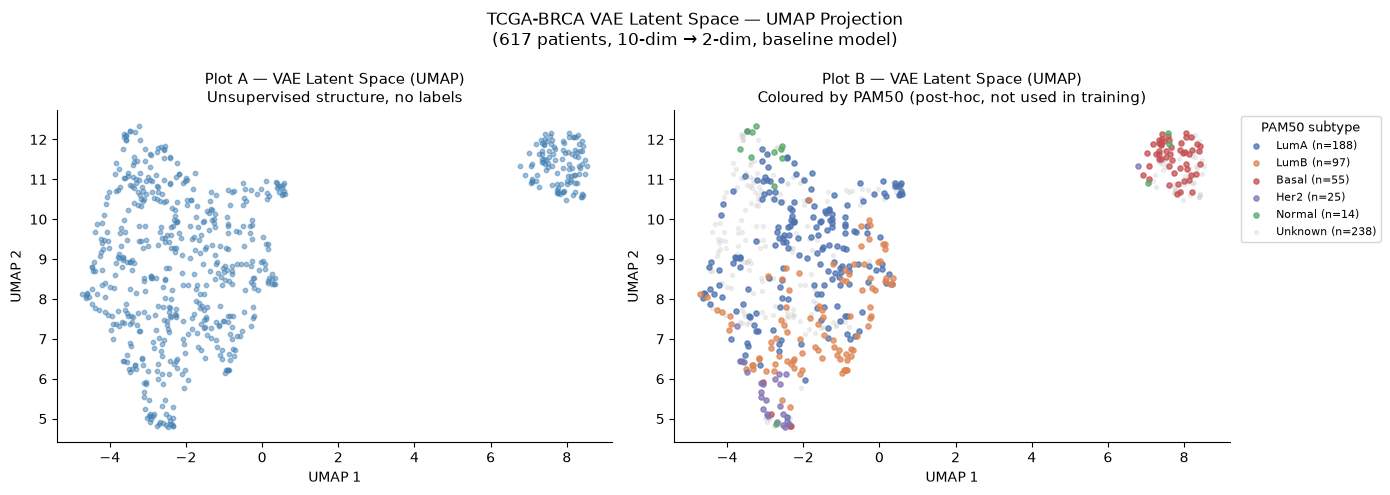

In [34]:
# ── PAM50 colour palette ───────────────────────────────────────────────────────
SUBTYPE_ORDER  = ["LumA", "LumB", "Basal", "Her2", "Normal", "Unknown"]
SUBTYPE_COLORS = {
    "LumA"   : "#4C72B0",
    "LumB"   : "#DD8452",
    "Basal"  : "#C44E52",
    "Her2"   : "#8172B3",
    "Normal" : "#55A868",
    "Unknown": "#CCCCCC",
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Plot A: No annotation (unsupervised structure) ─────────────────────────────
axes[0].scatter(Z_2d[:, 0], Z_2d[:, 1], s=10, color="steelblue",
                alpha=0.5, rasterized=True)
axes[0].set_title("Plot A — VAE Latent Space (UMAP)\n"
                  "Unsupervised structure, no labels",
                  fontsize=11)
axes[0].set_xlabel("UMAP 1"); axes[0].set_ylabel("UMAP 2")
axes[0].spines[["top", "right"]].set_visible(False)

# ── Plot B: Coloured by PAM50 (post-hoc only) ─────────────────────────────────
for st in SUBTYPE_ORDER:
    mask = pam50_labels.values == st
    if mask.sum() == 0:
        continue
    alpha = 0.3 if st == "Unknown" else 0.75
    size  = 8   if st == "Unknown" else 14
    axes[1].scatter(Z_2d[mask, 0], Z_2d[mask, 1],
                    s=size, color=SUBTYPE_COLORS[st], alpha=alpha,
                    label=f"{st} (n={mask.sum()})", rasterized=True, zorder=2 if st != "Unknown" else 1)

axes[1].set_title("Plot B — VAE Latent Space (UMAP)\n"
                  "Coloured by PAM50 (post-hoc, not used in training)",
                  fontsize=11)
axes[1].set_xlabel("UMAP 1"); axes[1].set_ylabel("UMAP 2")
axes[1].legend(title="PAM50 subtype", bbox_to_anchor=(1.01, 1), loc="upper left",
               fontsize=8, title_fontsize=9)
axes[1].spines[["top", "right"]].set_visible(False)

plt.suptitle("TCGA-BRCA VAE Latent Space — UMAP Projection\n"
             "(617 patients, 10-dim → 2-dim, baseline model)",
             fontsize=12)
plt.tight_layout()
plt.savefig(PROCESSED_DIR / "TCGA_BRCA_VAE_UMAP_PAM50.png",
            dpi=150, bbox_inches="tight")
plt.show()

K-means cluster sizes (k=5, on 10-D latent space):
  Cluster 0: 164 samples
  Cluster 1: 112 samples
  Cluster 2: 113 samples
  Cluster 3: 92 samples
  Cluster 4: 136 samples


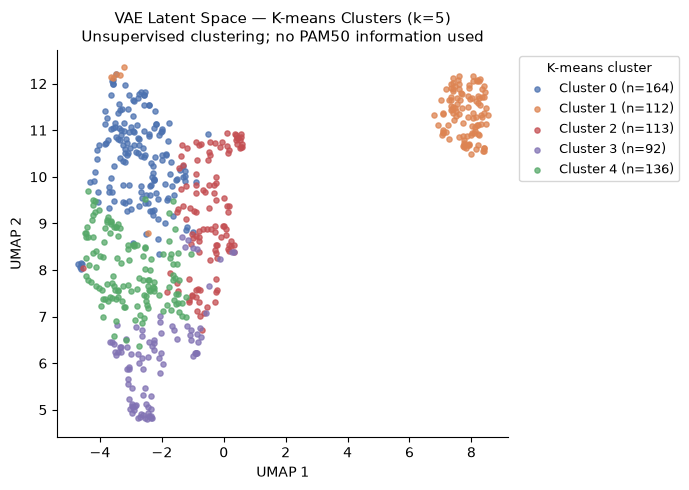

In [35]:
# ── K-means clustering on 10-D latent space (no labels) ──────────────────────
K = 5   # chosen to match number of PAM50 subtypes; NOT fitted to labels

km = KMeans(n_clusters=K, random_state=VAE_SEED, n_init=20)
cluster_labels = km.fit_predict(latent_df.values)   # operates on 10-D latent, no PAM50

cluster_sizes = pd.Series(cluster_labels).value_counts().sort_index()
print("K-means cluster sizes (k=5, on 10-D latent space):")
for c, n in cluster_sizes.items():
    print(f"  Cluster {c}: {n} samples")

# ── UMAP coloured by cluster ───────────────────────────────────────────────────
cluster_palette = {i: c for i, c in enumerate(
    ["#4C72B0", "#DD8452", "#C44E52", "#8172B3", "#55A868"])}

fig, ax = plt.subplots(figsize=(7, 5))
for c in range(K):
    mask = cluster_labels == c
    ax.scatter(Z_2d[mask, 0], Z_2d[mask, 1],
               s=14, color=cluster_palette[c], alpha=0.75,
               label=f"Cluster {c} (n={mask.sum()})", rasterized=True)

ax.set_title("VAE Latent Space — K-means Clusters (k=5)\n"
             "Unsupervised clustering; no PAM50 information used",
             fontsize=11)
ax.set_xlabel("UMAP 1"); ax.set_ylabel("UMAP 2")
ax.legend(title="K-means cluster", bbox_to_anchor=(1.01, 1),
          loc="upper left", fontsize=9, title_fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(PROCESSED_DIR / "TCGA_BRCA_VAE_UMAP_clusters.png",
            dpi=150, bbox_inches="tight")
plt.show()

Samples with PAM50 labels : 379 / 617

Contingency table (counts):
PAM50 subtype    LumA  LumB  Basal  Her2  Normal
K-means cluster                                 
0                  73     5      0     1       7
1                   0     1     51     1       6
2                  56    31      0     0       0
3                  12    41      4    22       1
4                  47    19      0     1       0

Adjusted Rand Index (ARI) : 0.2396
Normalised Mutual Info (NMI): 0.3860

Interpretation:
  ARI = 1.0 → perfect agreement; ARI = 0 → random agreement
  NMI = 1.0 → perfect mutual information; NMI = 0 → none

⚠️  ARI and NMI measure agreement between unsupervised clusters and PAM50.
   They do NOT prove that the VAE rediscovered PAM50 subtypes.
   The VAE integrates 3 modalities and is not optimised to reproduce PAM50.


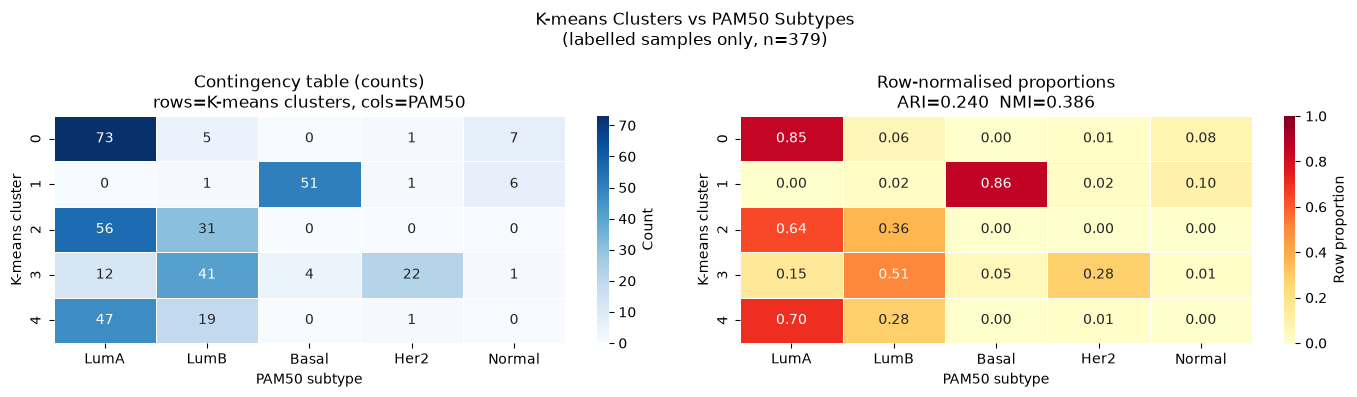

In [36]:
# ── Restrict to samples with known PAM50 labels for contingency analysis ───────
has_pam50_mask = pam50_labels.values != "Unknown"
clusters_labelled = cluster_labels[has_pam50_mask]
pam50_labelled    = pam50_labels.values[has_pam50_mask]

n_labelled = has_pam50_mask.sum()
print(f"Samples with PAM50 labels : {n_labelled} / 617")

# ── Contingency table ─────────────────────────────────────────────────────────
contingency = pd.crosstab(
    pd.Series(clusters_labelled, name="K-means cluster"),
    pd.Series(pam50_labelled,    name="PAM50 subtype"),
)
# Ensure consistent column ordering
for st in SUBTYPE_ORDER[:-1]:   # exclude "Unknown"
    if st not in contingency.columns:
        contingency[st] = 0
contingency = contingency[[s for s in SUBTYPE_ORDER if s in contingency.columns]]

print("\nContingency table (counts):")
print(contingency.to_string())

# ── ARI and NMI ───────────────────────────────────────────────────────────────
ari = adjusted_rand_score(pam50_labelled, clusters_labelled)
nmi = normalized_mutual_info_score(pam50_labelled, clusters_labelled, average_method="arithmetic")

print(f"\nAdjusted Rand Index (ARI) : {ari:.4f}")
print(f"Normalised Mutual Info (NMI): {nmi:.4f}")
print()
print("Interpretation:")
print("  ARI = 1.0 → perfect agreement; ARI = 0 → random agreement")
print("  NMI = 1.0 → perfect mutual information; NMI = 0 → none")
print()
print("⚠️  ARI and NMI measure agreement between unsupervised clusters and PAM50.")
print("   They do NOT prove that the VAE rediscovered PAM50 subtypes.")
print("   The VAE integrates 3 modalities and is not optimised to reproduce PAM50.")

# ── Normalised contingency heatmap ────────────────────────────────────────────
contingency_norm = contingency.div(contingency.sum(axis=1), axis=0)   # row proportions

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.heatmap(contingency, annot=True, fmt="d", cmap="Blues",
            ax=axes[0], linewidths=0.5, cbar_kws={"label": "Count"})
axes[0].set_title("Contingency table (counts)\nrows=K-means clusters, cols=PAM50")

sns.heatmap(contingency_norm.round(2), annot=True, fmt=".2f",
            cmap="YlOrRd", ax=axes[1], linewidths=0.5,
            vmin=0, vmax=1, cbar_kws={"label": "Row proportion"})
axes[1].set_title(f"Row-normalised proportions\nARI={ari:.3f}  NMI={nmi:.3f}")

plt.suptitle("K-means Clusters vs PAM50 Subtypes\n"
             "(labelled samples only, n={})".format(n_labelled), fontsize=12)
plt.tight_layout()
plt.savefig(PROCESSED_DIR / "TCGA_BRCA_VAE_contingency.png",
            dpi=150, bbox_inches="tight")
plt.show()

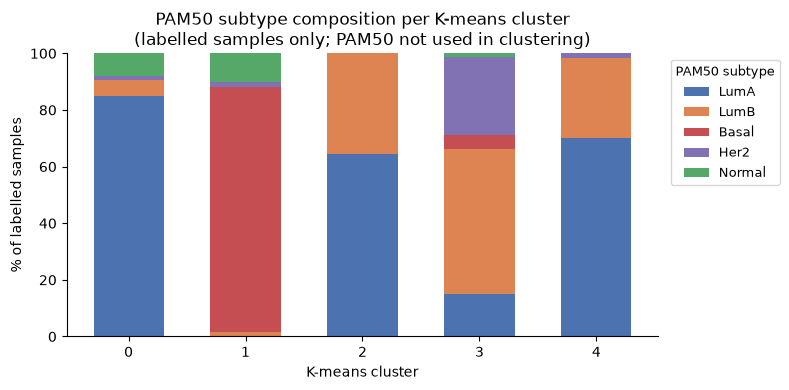

Cluster compositions (% PAM50 in labelled samples per cluster):
PAM50    LumA  LumB  Basal  Her2  Normal
cluster                                 
0        84.9   5.8    0.0   1.2     8.1
1         0.0   1.7   86.4   1.7    10.2
2        64.4  35.6    0.0   0.0     0.0
3        15.0  51.2    5.0  27.5     1.2
4        70.1  28.4    0.0   1.5     0.0


In [37]:
# ── Stacked bar chart: PAM50 composition within each cluster ──────────────────
cluster_pam50 = pd.DataFrame({
    "cluster": cluster_labels[has_pam50_mask],
    "PAM50"  : pam50_labelled,
})
stacked = cluster_pam50.groupby(["cluster", "PAM50"]).size().unstack(fill_value=0)
# Ensure column order
stacked = stacked.reindex(columns=[s for s in SUBTYPE_ORDER if s in stacked.columns], fill_value=0)
stacked_pct = stacked.div(stacked.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(8, 4))
bottom = np.zeros(len(stacked_pct))
for st in stacked_pct.columns:
    ax.bar(stacked_pct.index, stacked_pct[st], bottom=bottom,
           color=SUBTYPE_COLORS.get(st, "#999"), label=st, width=0.6)
    bottom += stacked_pct[st].values

ax.set_xlabel("K-means cluster"); ax.set_ylabel("% of labelled samples")
ax.set_title("PAM50 subtype composition per K-means cluster\n"
             "(labelled samples only; PAM50 not used in clustering)")
ax.legend(title="PAM50 subtype", bbox_to_anchor=(1.01, 1),
          loc="upper left", fontsize=9, title_fontsize=9)
ax.set_ylim(0, 100)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(PROCESSED_DIR / "TCGA_BRCA_VAE_cluster_composition.png",
            dpi=150, bbox_inches="tight")
plt.show()

print("Cluster compositions (% PAM50 in labelled samples per cluster):")
print(stacked_pct.round(1).to_string())

---

## Part 16b — Lightweight AI Enhancement: VAE vs Plain Autoencoder (Nonlinear Deep Representation Learning)

Both the **Variational Autoencoder (VAE)** and a plain **Autoencoder (AE)** are *nonlinear deep representation learning* methods for multi-omics integration. Each learns a compressed 10-dimensional patient representation from the same 2,300 concatenated RNA-seq + miRNA + methylation features:

- **AE** — a deterministic nonlinear map `encoder: ℝ²³⁰⁰ → ℝ¹⁰` trained purely to minimise reconstruction MSE. It has full freedom to use the bottleneck however it likes.
- **VAE** — the same encoder/decoder topology, but the encoder outputs a distribution `(μ, log σ²)` and training adds a KL-divergence term pulling the posterior toward `N(0, I)`. This regularisation sacrifices some reconstruction fidelity in exchange for a **smooth, continuous latent manifold** that is better suited to clustering and subtyping.

**Why compare them?** If the AE reconstructs much better than the VAE, it suggests the KL constraint is over-regularising; if they are comparable, the VAE's probabilistic structure comes essentially "for free". This is a lightweight ablation of what the variational objective actually buys us.

**Protocol:** identical inputs (frozen 617-patient cohort), identical 10-D latent dimension, identical train/validation split and per-modality scaling as Part 15, short CPU-friendly training with early stopping. PAM50 is used **only post-hoc** as an external biological reference.

In [38]:
import random, time, json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# ── Paths & seeds (identical protocol to Part 15) ─────────────────────────────
FIG_DIR = PROCESSED_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

random.seed(VAE_SEED); np.random.seed(VAE_SEED); torch.manual_seed(VAE_SEED)

# ── Load frozen processed matrices (unchanged inputs) ─────────────────────────
rna_df   = pd.read_csv(PROCESSED_DIR / "TCGA_BRCA_RNA_selected.tsv",   sep="\t", index_col=0)
mirna_df = pd.read_csv(PROCESSED_DIR / "TCGA_BRCA_miRNA_selected.tsv", sep="\t", index_col=0)
meth_df  = pd.read_csv(PROCESSED_DIR / "TCGA_BRCA_methylation_selected.tsv", sep="\t", index_col=0)
cohort_meta = pd.read_csv(PROCESSED_DIR / "TCGA_BRCA_cohort_metadata.tsv", sep="\t", index_col="sample_id")
frozen_ids = cohort_meta.index.tolist()

assert list(rna_df.index) == list(mirna_df.index) == list(meth_df.index) == frozen_ids

# ── Same split & scaling as the VAE section (identical seed → identical split) ─
VAL_FRAC, BATCH_SIZE = 0.20, 64
sample_array = np.array(frozen_ids)
idx_all = np.arange(len(sample_array))
idx_train, idx_val = train_test_split(idx_all, test_size=VAL_FRAC,
                                      random_state=VAE_SEED, shuffle=True)
train_ids = sample_array[idx_train].tolist()

def fit_scale(df, tr_ids):
    sc = StandardScaler().fit(df.loc[tr_ids].values)
    return sc.transform(df.values).astype(np.float32)

X_all = np.concatenate([fit_scale(rna_df, train_ids),
                        fit_scale(mirna_df, train_ids),
                        fit_scale(meth_df, train_ids)], axis=1)
INPUT_DIM = X_all.shape[1]
LATENT_DIM = 10

X_tensor = torch.tensor(X_all, dtype=torch.float32)
X_train_t, X_val_t = X_tensor[idx_train], X_tensor[idx_val]
train_loader = DataLoader(TensorDataset(X_train_t), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_val_t),   batch_size=BATCH_SIZE, shuffle=False)

print(f"Figures dir : {FIG_DIR}")
print(f"Cohort      : {len(frozen_ids)} samples | input dim {INPUT_DIM} | latent {LATENT_DIM}")
print(f"Train/val   : {len(idx_train)}/{len(idx_val)} (same split & scaling as VAE)")

Figures dir : C:\Users\abhij\iisc\AI-Driven-MultiOmics-Workshop\data\processed\figures
Cohort      : 617 samples | input dim 2300 | latent 10
Train/val   : 493/124 (same split & scaling as VAE)


In [39]:
class AE(nn.Module):
    """Same encoder/decoder topology as the VAE, but deterministic bottleneck
    (no mu/logvar heads, no KL term)."""
    def __init__(self, input_dim, latent_dim):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 256), nn.BatchNorm1d(256), nn.ReLU(),
            nn.Linear(256, 64),        nn.BatchNorm1d(64),  nn.ReLU(),
            nn.Linear(64, latent_dim),
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64),  nn.BatchNorm1d(64),  nn.ReLU(),
            nn.Linear(64, 256),         nn.BatchNorm1d(256), nn.ReLU(),
            nn.Linear(256, input_dim),
        )
    def forward(self, x):
        return self.decoder(self.encoder(x))

torch.manual_seed(VAE_SEED)
ae = AE(INPUT_DIM, LATENT_DIM)
ae_n_params = sum(p.numel() for p in ae.parameters() if p.requires_grad)
print("AE architecture:")
print(ae)
print(f"\nTrainable parameters: {ae_n_params:,}")

LR, MAX_EPOCHS, PATIENCE = 1e-3, 100, 15
AE_CKPT = PROCESSED_DIR / "TCGA_BRCA_AE_best.pt"
opt = torch.optim.Adam(ae.parameters(), lr=LR)
ae_history = {"train_recon": [], "val_recon": []}
best_val, best_epoch, patience_ct = float("inf"), 0, 0
t0 = time.time()

for epoch in range(1, MAX_EPOCHS + 1):
    ae.train()
    tr = 0.0
    for (xb,) in train_loader:
        opt.zero_grad()
        loss = F.mse_loss(ae(xb), xb, reduction="mean")
        loss.backward(); opt.step()
        tr += loss.item()
    ae_history["train_recon"].append(tr / len(train_loader))

    ae.eval()
    va = 0.0
    with torch.no_grad():
        for (xb,) in val_loader:
            va += F.mse_loss(ae(xb), xb, reduction="mean").item()
    va /= len(val_loader)
    ae_history["val_recon"].append(va)

    if va < best_val:
        best_val, best_epoch, patience_ct = va, epoch, 0
        torch.save({"epoch": epoch, "model_state": ae.state_dict(), "val_recon": va}, AE_CKPT)
    else:
        patience_ct += 1
        if patience_ct >= PATIENCE:
            print(f"Early stopping at epoch {epoch} (no improvement for {PATIENCE} epochs)")
            break
    if epoch % 10 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d} | train recon={ae_history['train_recon'][-1]:.5f} "
              f"| val recon={va:.5f}")

elapsed = time.time() - t0
ckpt = torch.load(AE_CKPT, weights_only=True)
ae.load_state_dict(ckpt["model_state"]); ae.eval()
ae_best_epoch = ckpt["epoch"]
print(f"\nTraining finished: {len(ae_history['train_recon'])} epochs in {elapsed:.1f}s")
print(f"Best epoch: {ae_best_epoch} | best val recon (MSE): {best_val:.5f}")

AE architecture:
AE(
  (encoder): Sequential(
    (0): Linear(in_features=2300, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=64, bias=True)
    (4): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (5): ReLU()
    (6): Linear(in_features=64, out_features=10, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=10, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Linear(in_features=64, out_features=256, bias=True)
    (4): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (5): ReLU()
    (6): Linear(in_features=256, out_features=2300, bias=True)
  )
)

Trainable parameters: 1,215,878
Epoch   1 | train recon=1.01987 | val recon=0.87790


---

### Reconstruction-loss comparison

The AE is expected to reconstruct at least as well as the VAE (it spends all capacity on reconstruction). The key question is *how large the gap is*.

Reconstruction loss on validation set (MSE, mean over elements)
  VAE : 0.59280   (best epoch 69)
  AE  : 0.58143   (best epoch 36)
  Δ (AE − VAE): -0.01137 (-1.92%)

Interpretation: reconstruction quality is essentially comparable.
The VAE's advantage lies in its smooth, probabilistic latent space
(regularised by the KL term toward N(0,I)), not in lower MSE.


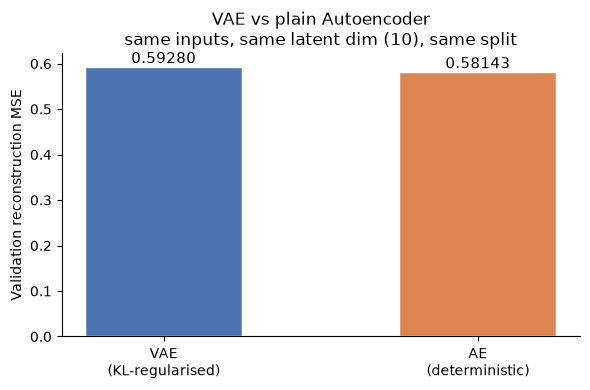

✅ Saved: data/processed/figures/VAE_vs_AE_reconstruction.png
✅ Saved: data/processed/TCGA_BRCA_VAE_vs_AE_comparison.json


In [40]:
# ── Rebuild the trained VAE exactly as in Part 15 and evaluate both on val set ─
class _Encoder(nn.Module):
    def __init__(self, input_dim, latent_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256), nn.BatchNorm1d(256), nn.ReLU(),
            nn.Linear(256, 64), nn.BatchNorm1d(64), nn.ReLU())
        self.fc_mu = nn.Linear(64, latent_dim)
        self.fc_logvar = nn.Linear(64, latent_dim)
    def forward(self, x):
        h = self.net(x); return self.fc_mu(h), self.fc_logvar(h)

class _Decoder(nn.Module):
    def __init__(self, latent_dim, output_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 64), nn.BatchNorm1d(64), nn.ReLU(),
            nn.Linear(64, 256), nn.BatchNorm1d(256), nn.ReLU(),
            nn.Linear(256, output_dim))
    def forward(self, z): return self.net(z)

class _VAE(nn.Module):
    def __init__(self, input_dim, latent_dim):
        super().__init__()
        self.encoder = _Encoder(input_dim, latent_dim)
        self.decoder = _Decoder(latent_dim, input_dim)
    def forward(self, x):
        mu, logvar = self.encoder(x)
        return self.decoder(mu), mu, logvar

ckpt_vae = torch.load(PROCESSED_DIR / "TCGA_BRCA_VAE_best.pt", weights_only=True)
vae_cmp = _VAE(INPUT_DIM, LATENT_DIM)
vae_cmp.load_state_dict(ckpt_vae["model_state"]); vae_cmp.eval()

with torch.no_grad():
    vr = ar = 0.0
    for (xb,) in val_loader:
        x_hat, _, _ = vae_cmp(xb)
        vr += F.mse_loss(x_hat, xb, reduction="mean").item()
        ar += F.mse_loss(ae(xb), xb, reduction="mean").item()
    vae_val_recon = vr / len(val_loader)
    ae_val_recon  = ar / len(val_loader)

comparison = {
    "vae_val_recon_mse": round(vae_val_recon, 6),
    "ae_val_recon_mse":  round(ae_val_recon, 6),
    "delta_ae_minus_vae": round(ae_val_recon - vae_val_recon, 6),
    "pct_difference": round(100 * (ae_val_recon - vae_val_recon) / vae_val_recon, 2),
    "vae_best_epoch": ckpt_vae["epoch"],
    "ae_best_epoch": ae_best_epoch,
    "ae_params": ae_n_params,
}
print("Reconstruction loss on validation set (MSE, mean over elements)")
print("=" * 55)
print(f"  VAE : {vae_val_recon:.5f}   (best epoch {ckpt_vae['epoch']})")
print(f"  AE  : {ae_val_recon:.5f}   (best epoch {ae_best_epoch})")
d = ae_val_recon - vae_val_recon
print(f"  Δ (AE − VAE): {d:+.5f} ({comparison['pct_difference']:+.2f}%)")
print()
if abs(d) < 0.02 * vae_val_recon:
    print("Interpretation: reconstruction quality is essentially comparable.")
    print("The VAE's advantage lies in its smooth, probabilistic latent space")
    print("(regularised by the KL term toward N(0,I)), not in lower MSE.")
elif d > 0:
    print("Interpretation: the AE reconstructs slightly better — expected, since")
    print("it spends ALL of its capacity on reconstruction with no KL constraint.")
else:
    print("Interpretation: the VAE reconstructs slightly better despite the KL")
    print("constraint acting as a regulariser against overfitting.")

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(["VAE\n(KL-regularised)", "AE\n(deterministic)"],
              [vae_val_recon, ae_val_recon],
              color=["#4C72B0", "#DD8452"], edgecolor="white", width=0.5)
for b, v in zip(bars, [vae_val_recon, ae_val_recon]):
    ax.text(b.get_x() + b.get_width()/2, v + 0.0002, f"{v:.5f}",
            ha="center", va="bottom", fontsize=11)
ax.set_ylabel("Validation reconstruction MSE")
ax.set_title("VAE vs plain Autoencoder\nsame inputs, same latent dim (10), same split")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(FIG_DIR / "VAE_vs_AE_reconstruction.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved: data/processed/figures/VAE_vs_AE_reconstruction.png")

with open(PROCESSED_DIR / "TCGA_BRCA_VAE_vs_AE_comparison.json", "w") as fh:
    json.dump(comparison, fh, indent=2)
print("✅ Saved: data/processed/TCGA_BRCA_VAE_vs_AE_comparison.json")

---

### Latent-space comparison via UMAP (PAM50 post-hoc only)

UMAP embeddings of both 10-D latent spaces are computed **without any labels**. PAM50 colours are overlaid afterwards purely as an external biological reference — they play no role in the models, the UMAP fitting, or the clustering.

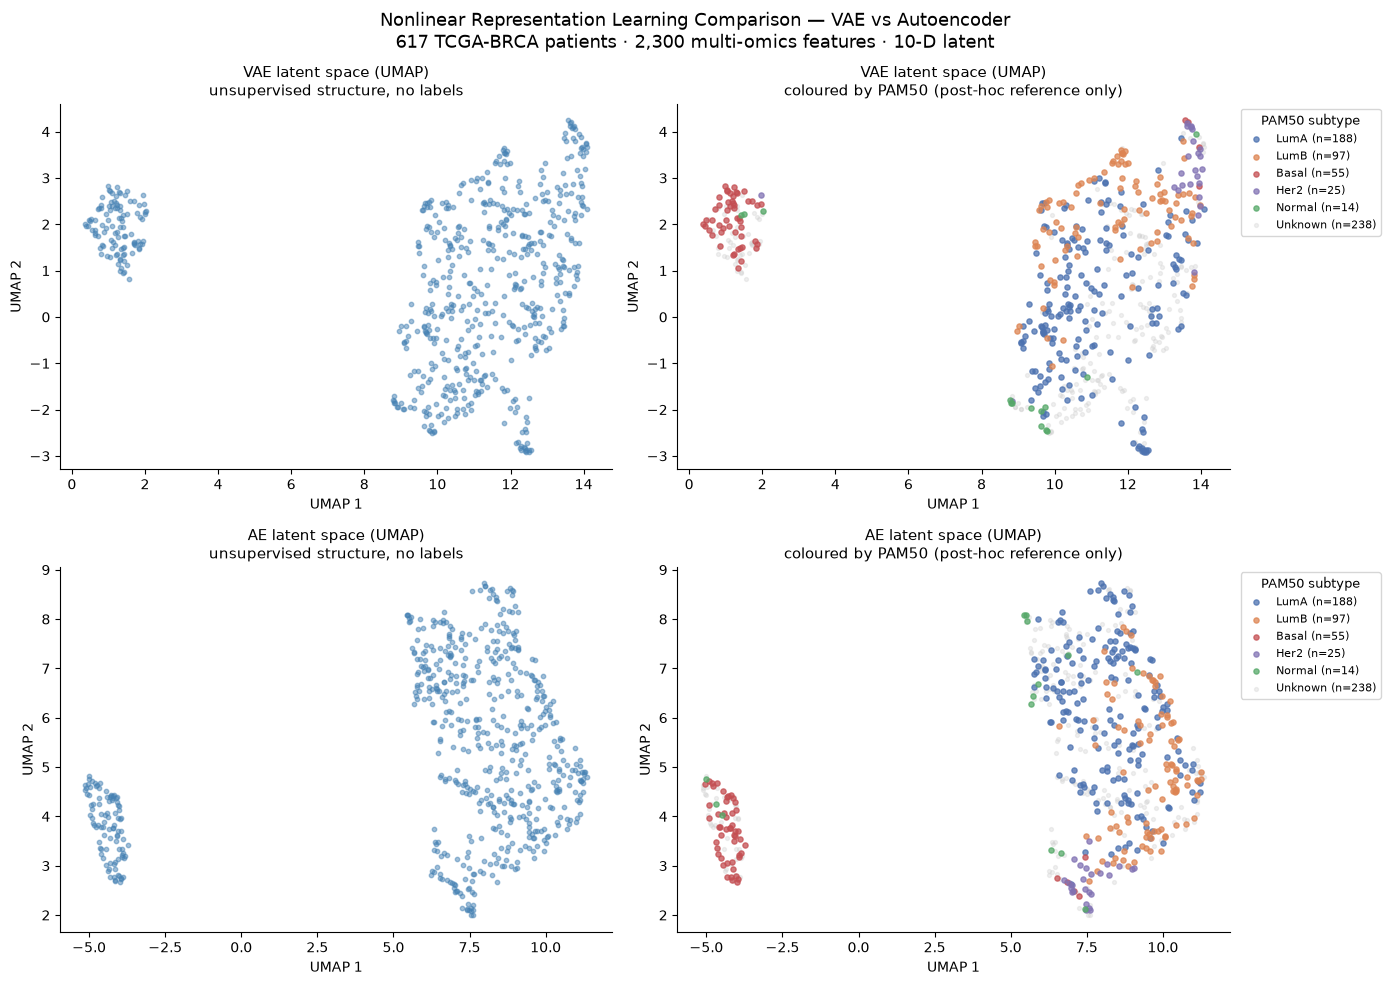

✅ Saved: data/processed/figures/VAE_vs_AE_UMAP_PAM50.png

Post-hoc PAM50 agreement (k-means k=5 on 10-D latent; labels NOT used in fitting):
       ARI_vs_PAM50  NMI_vs_PAM50
model                            
VAE          0.2396        0.3860
AE           0.2741        0.4377

⚠️  PAM50 used strictly post-hoc as an external biological reference.
✅ Saved: data/processed/TCGA_BRCA_VAE_vs_AE_PAM50_posthoc.tsv


In [41]:
import umap as umap_lib
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from sklearn.cluster import KMeans

# ── Extract latents (no labels used anywhere in the embedding) ────────────────
with torch.no_grad():
    z_vae = vae_cmp.encoder(X_tensor)[0].numpy()          # mu, (617, 10)
    z_ae  = ae.encoder(X_tensor).numpy()                  # (617, 10)

pam50_labels = cohort_meta["PAM50_subtype"].reindex(frozen_ids).fillna("Unknown")

reducer_vae = umap_lib.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=42)
reducer_ae  = umap_lib.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=42)
emb_vae = reducer_vae.fit_transform(z_vae)
emb_ae  = reducer_ae.fit_transform(z_ae)

SUBTYPE_ORDER  = ["LumA", "LumB", "Basal", "Her2", "Normal", "Unknown"]
SUBTYPE_COLORS = {"LumA": "#4C72B0", "LumB": "#DD8452", "Basal": "#C44E52",
                  "Her2": "#8172B3", "Normal": "#55A868", "Unknown": "#CCCCCC"}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for row, (emb, name) in enumerate([(emb_vae, "VAE"), (emb_ae, "AE")]):
    axes[row, 0].scatter(emb[:, 0], emb[:, 1], s=10, color="steelblue",
                         alpha=0.5, rasterized=True)
    axes[row, 0].set_title(f"{name} latent space (UMAP)\nunsupervised structure, no labels",
                           fontsize=11)
    axes[row, 0].set_xlabel("UMAP 1"); axes[row, 0].set_ylabel("UMAP 2")
    axes[row, 0].spines[["top", "right"]].set_visible(False)

    for st in SUBTYPE_ORDER:
        mask = pam50_labels.values == st
        if mask.sum() == 0:
            continue
        alpha = 0.3 if st == "Unknown" else 0.75
        size  = 8   if st == "Unknown" else 14
        axes[row, 1].scatter(emb[mask, 0], emb[mask, 1], s=size,
                             color=SUBTYPE_COLORS[st], alpha=alpha,
                             label=f"{st} (n={mask.sum()})", rasterized=True,
                             zorder=2 if st != "Unknown" else 1)
    axes[row, 1].set_title(f"{name} latent space (UMAP)\ncoloured by PAM50 (post-hoc reference only)",
                           fontsize=11)
    axes[row, 1].set_xlabel("UMAP 1"); axes[row, 1].set_ylabel("UMAP 2")
    axes[row, 1].legend(title="PAM50 subtype", bbox_to_anchor=(1.01, 1),
                        loc="upper left", fontsize=8, title_fontsize=9)
    axes[row, 1].spines[["top", "right"]].set_visible(False)

plt.suptitle("Nonlinear Representation Learning Comparison — VAE vs Autoencoder\n"
             "617 TCGA-BRCA patients · 2,300 multi-omics features · 10-D latent",
             fontsize=13)
plt.tight_layout()
plt.savefig(FIG_DIR / "VAE_vs_AE_UMAP_PAM50.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved: data/processed/figures/VAE_vs_AE_UMAP_PAM50.png")

# ── Post-hoc quantitative check: k-means (k=5) vs PAM50, labelled samples only ─
rows = []
has_lbl = pam50_labels.values != "Unknown"
for z, name in [(z_vae, "VAE"), (z_ae, "AE")]:
    km = KMeans(n_clusters=5, random_state=42, n_init=20).fit_predict(z)
    ari = adjusted_rand_score(pam50_labels.values[has_lbl], km[has_lbl])
    nmi = normalized_mutual_info_score(pam50_labels.values[has_lbl], km[has_lbl])
    rows.append({"model": name, "ARI_vs_PAM50": round(ari, 4),
                 "NMI_vs_PAM50": round(nmi, 4)})
posthoc = pd.DataFrame(rows).set_index("model")
print("\nPost-hoc PAM50 agreement (k-means k=5 on 10-D latent; labels NOT used in fitting):")
print(posthoc.to_string())
print("\n⚠️  PAM50 used strictly post-hoc as an external biological reference.")

posthoc.to_csv(PROCESSED_DIR / "TCGA_BRCA_VAE_vs_AE_PAM50_posthoc.tsv", sep="\t")
print("✅ Saved: data/processed/TCGA_BRCA_VAE_vs_AE_PAM50_posthoc.tsv")

Notebook 1 demonstrates how nonlinear deep representation learning can compress heterogeneous multi-omics measurements into a low-dimensional patient representation. Both the VAE and AE captured meaningful molecular structure without using PAM50 during training. The AE achieved slightly lower reconstruction error and somewhat higher post-hoc PAM50 agreement, while the VAE provides the additional benefit of a probabilistically regularized latent space.